## Introduction

This project was carried out as part of a machine learning study focused on supervised and unsupervised learning methods. The dataset used in this project relates to vehicles that have been taken off the road and are in a final cancellation status. The analysis aims to explore patterns, predict outcomes, and optimize decision-making processes regarding these vehicles.

The work is divided into two main parts:
1. **Supervised Learning**: Implementing and optimizing models to predict specific outcomes based on labeled data.
2. **Unsupervised Learning**: Applying clustering and pattern identification techniques to uncover hidden structures in the data.

The project was a collaborative effort, combining data preprocessing, supervised learning implementation, and unsupervised analysis to derive meaningful insights from the dataset.

**Submitted by**: Gal Ben Lulu and Itay Habsha.


## Importing Libraries

In [3]:
# Standard Libraries
import requests
import numpy as np

# Data Manipulation
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data Imputation
from sklearn.impute import KNNImputer, SimpleImputer

# Display Utilities
from IPython.display import display

# Model imports
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

# Metrics imports
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.model_selection import GridSearchCV, cross_val_score, learning_curve

# Dimensionality Reduction
from sklearn.decomposition import PCA, KernelPCA

# Feature Selection
from sklearn.feature_selection import SelectKBest, f_classif, RFE

# Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
import category_encoders as ce

# Clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Handle warnings
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Sampling
from imblearn.over_sampling import SMOTE

# Train-Test Split
from sklearn.model_selection import train_test_split

### Function In Use 

In [5]:
def calculate_correlation(df, column1, column2, method='pearson'):
    correlation = df[[column1, column2]].dropna().corr(method=method)
    return correlation.loc[column1, column2]

def calculate_and_print_equal_percentage(df, column1, column2):
    valid_rows = df[[column1, column2]].dropna()
    equal_values_count = (valid_rows[column1] == valid_rows[column2]).sum()
    total_valid_rows = len(valid_rows)
    percentage_equal = (equal_values_count / total_valid_rows) * 100
    print(f"Percentage of rows where '{column1}' equals '{column2}': {percentage_equal:.2f}%")



def plot_distribution(column_data, title='Distribution', xlabel='Category', ylabel='Count', figsize=(6, 4)):
    value_counts = column_data.value_counts().sort_index()
    plt.figure(figsize=figsize)
    ax = value_counts.plot(kind='bar', color='royalblue', edgecolor='black', width=0.8)
    plt.title(title, fontsize=16, fontweight='bold')
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(fontsize=10)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.gcf().set_facecolor('white')
    plt.tight_layout()
    plt.show()



def plot_weight_distribution(column_data, title='Distribution of Total Weight', xlabel='Total Weight', ylabel='Number of Vehicles', figsize=(10, 6), bins=50, max_value=5000):
    filtered_data = column_data[column_data <= max_value]
    
    plt.figure(figsize=figsize)
    plt.hist(filtered_data, bins=bins, color='royalblue', edgecolor='black')
    
    plt.xticks(range(0, max_value + 1, 500))
    
    # עיצוב הגרף
    plt.title(title, fontsize=16, fontweight='bold')
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(fontsize=10)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.gcf().set_facecolor('white')
    plt.tight_layout()
    plt.show()

def anova_f_test_feature_selection(X_train, y_train, k='all'):
    selector = SelectKBest(score_func=f_classif, k=k)
    selector.fit(X_train, y_train)
    f_scores = selector.scores_
    p_values = selector.pvalues_
    selected_features = X_train.columns[selector.get_support()]
    results = pd.DataFrame({
        'Feature': X_train.columns,
        'F-Score': f_scores,
        'p-Value': p_values
    }) 
    results.sort_values(by='F-Score', ascending=False, inplace=True)
    print(f"Selected Features (Top {k}):")
    print(selected_features.tolist())
    colors = plt.cm.Paired(np.arange(len(results)))
    plt.figure(figsize=(8, 4))
    plt.bar(results['Feature'], results['F-Score'], color=colors)
    plt.xlabel('Features')
    plt.ylabel('F-Score')
    plt.title('ANOVA F-Test Feature Selection')
    plt.xticks(rotation=45)
    plt.show()
    
    return results


def apply_smote(X_train, y_train):
    # Apply SMOTE
    X_resampled, y_resampled = SMOTE(random_state=42).fit_resample(X_train, y_train)
    print("Original class distribution:", y_train.value_counts())
    print("Resampled class distribution:", pd.Series(y_resampled).value_counts())
    
    plt.figure(figsize=(14, 6))
    
    # Pie chart
    plt.subplot(1, 2, 1)
    plt.pie(
        pd.Series(y_resampled).value_counts(), 
        labels=pd.Series(y_resampled).value_counts().index, 
        autopct='%1.1f%%', 
        colors=sns.color_palette("Blues", len(pd.Series(y_resampled).value_counts())), 
        startangle=90
    )
    plt.title('Class Distribution After SMOTE', fontsize=16, fontweight='bold')
    
    # Countplot
    plt.subplot(1, 2, 2)
    sns.countplot(
        x=pd.Series(y_resampled), 
        edgecolor='black',
        color=sns.color_palette("Blues", 1)[0]  # Use a single color for bars
    )
    plt.title('Class Count After SMOTE', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return X_resampled, y_resampled

## Supervised Learning 

### Fetching Data from a Government API and Converting to a DataFrame in Python

In [8]:
# API URL with a limit of 25,000 rows
url = 'https://data.gov.il/api/3/action/datastore_search?resource_id=851ecab1-0622-4dbe-a6c7-f950cf82abf9&limit=25000'
response = requests.get(url)
if response.status_code == 200:
    json_data = response.json()
    records = json_data['result']['records']  
    df = pd.DataFrame(records) 
    df = df.replace(r'^\s*$', None, regex=True)
else:
    print(f"Failed to fetch data, status code: {response.status_code}")

# ----------------------------------------------------------------------------------------

### Column Summary:
**mispar_rechev**: Numeric column denoting the unique identifier assigned to the vehicle.  
**tozeret_cd**: A numeric field that represents the manufacturer's unique code.  
**tozeret_nm**: A textual column describing the manufacturer’s name.  
**degem_cd**: A code (text-based) used to specify the model of the vehicle.  
**degem_nm**: A descriptive text field containing the model name of the vehicle.  
**sug_rechev_cd**: Numeric column used for categorizing the vehicle type via a code.  
**sug_rechev_nm**: A column that provides the type of the vehicle in text format.  
**moed_aliya_lakvish**: Text column indicating the date the vehicle was imported.  
**bitul_dt**: A text field specifying the cancellation date of the vehicle.  
**misgeret**: Textual data representing the vehicle’s structural classification.  
**tozar_manoa**: A field that holds the manufacturer’s engine code.  
**degem_manoa**: Text-based column representing the engine model.  
**mispar_manoa**: Represents the unique engine number for a given model.  
**mishkal_kolel**: A numerical value indicating the vehicle's total weight.  
**ramat_gimur**: Text column specifying the level of assembly or completion.  
**ramat_eivzur_betihuty**: A numerical field reflecting the vehicle's safety equipment rating.  
**kvutzat_zihum**: Numeric identifier for the pollution group to which the vehicle belongs.  
**shnat_yitzur**: A column specifying the year in which the vehicle was manufactured.  
**baalut**: Text field representing the ownership status or type.  
**tzeva_rechev**: A text field detailing the vehicle’s color.  
**zmig_kidmi**: Describes the type of front tire in text form.  
**zmig_ahori**: Represents the type of rear tire in textual format.  
**sug_delek_nm**: Text column indicating the type of fuel used by the vehicle.  
**horaat_rishum**: A numeric column reflecting the registration directive or code.  
**kinuy_mishari**: A textual field providing the commercial designation of the vehicle.

# ----------------------------------------------------------------------------------------

### Initial Data Overview 

In [13]:
df.head()

,_id,mispar_rechev,tozeret_cd,tozeret_nm,degem_cd,degem_nm,sug_rechev_cd,sug_rechev_nm,moed_aliya_lakvish,bitul_dt,...,ramat_eivzur_betihuty,kvutzat_zihum,shnat_yitzur,baalut,tzeva_rechev,zmig_kidmi,zmig_ahori,sug_delek_nm,horaat_rishum,kinuy_mishari
0,1,3109439,76,אופל אנגליה,13.0,PD8EC,112,פרטי נוסעים,2016.0,2024-01-02 00:00:00,...,0,15,2016,פרטי,שחור מטלי,215/60/R16,215/60/R16,בנזין,160217,ASTRA ST
1,2,4151579,653,ניסאן הודו,10.0,FBUK13,112,פרטי נוסעים,2012.0,2024-02-10 00:00:00,...,0,14,2012,פרטי,שנהב לבן,165/70 R14,165/70 R14,בנזין,110390,MICRA
2,3,6901413,817,סיטרואן צרפת,1241.0,NC5FS9/1,112,פרטי נוסעים,2012.0,2024-07-04 00:00:00,...,0,15,2012,פרטי,בז,205/55R16,205/55R16,בנזין,120046,C4
3,4,69877502,535,עטרייה מתכת,NaN,AT750,450,גרור פתוח,2021.0,2024-12-09 00:00:00,...,0,0,2021,פרטי,אפור,155/80R13,None,לא ידוע קוד 0,207201,None
4,5,21140101,771,רנו טורקיה,223.0,RFB00,112,פרטי נוסעים,2018.0,2024-12-01 00:00:00,...,0,13,2018,פרטי,אפור כהה מטלי,205/50R17,205/50R17,דיזל,160463,GRAND COUPE


In [14]:
print("Dataset Shape:", df.shape)

Dataset Shape: (25000, 26)


In [15]:
df.isnull().sum().sort_values()

_id                         0
ramat_eivzur_betihuty       0
baalut                      0
mishkal_kolel               0
tzeva_rechev                0
horaat_rishum               0
misgeret                    0
kvutzat_zihum               0
bitul_dt                    0
sug_rechev_nm               0
sug_rechev_cd               0
sug_delek_nm                0
tozeret_nm                  0
tozeret_cd                  0
mispar_rechev               0
shnat_yitzur                0
degem_nm                    1
zmig_kidmi                 36
tozar_manoa               183
degem_manoa               185
mispar_manoa              194
zmig_ahori               1765
degem_cd                 3940
kinuy_mishari            4038
ramat_gimur              4578
moed_aliya_lakvish       6140
dtype: int64

#### Removing Irrelevant Columns from the Dataset

identify columns where more than 90% of the values are unique:

In [18]:
summary = pd.DataFrame({
    "Column": df.columns,
    "Unique Percentage": (df.nunique() / df.notnull().sum() * 100)
})

filtered_summary = summary[summary["Unique Percentage"] >= 90]
print(filtered_summary)

                      Column  Unique Percentage
_id                      _id         100.000000
mispar_rechev  mispar_rechev         100.000000
misgeret            misgeret         100.000000
mispar_manoa    mispar_manoa          99.931468


The columns 'misgeret', '_id', 'mispar_rechev',and 'mispar_manoa' contain uniform values, providing no variability across rows. Such columns lack informational value and cannot contribute to the analysis or modeling. As a result, they are excluded from the process.

In [20]:
df.drop(['mispar_rechev','mispar_manoa','misgeret','_id'], axis=1, inplace=True)

##### Data Translation: Converting Categorical Values from Hebrew to English


In [22]:
df['baalut'].unique()

array(['פרטי', 'חברה', 'ליסינג', 'השכרה'], dtype=object)

In [23]:
ownership_mapping = {
    'פרטי': 'private',
    'ליסינג': 'leasing',
    'חברה': 'company',
    'השכרה': 'rent'
}
df['baalut'] = df['baalut'].map(ownership_mapping)
print(df['baalut'].unique())

['private' 'company' 'leasing' 'rent']


In [24]:
df['sug_delek_nm'].unique()

array(['בנזין', 'לא ידוע קוד 0', 'דיזל', 'חשמל', 'חשמל/בנזין', 'גפמ"',
       'חשמל/דיזל'], dtype=object)

In [25]:
fuel_mapping = {
    'בנזין': 'gasoline',
    'חשמל': 'electric',
    'לא ידוע קוד 0': np.nan,  
    'דיזל': 'diesel',
    'חשמל/בנזין': 'hybrid_gasoline',
    'גפמ"': 'lpg',
    'חשמל/דיזל': 'hybrid_diesel'
}
# Apply the mapping to the column
df['sug_delek_nm'] = df['sug_delek_nm'].map(fuel_mapping)

#### Target Variable Analysis 

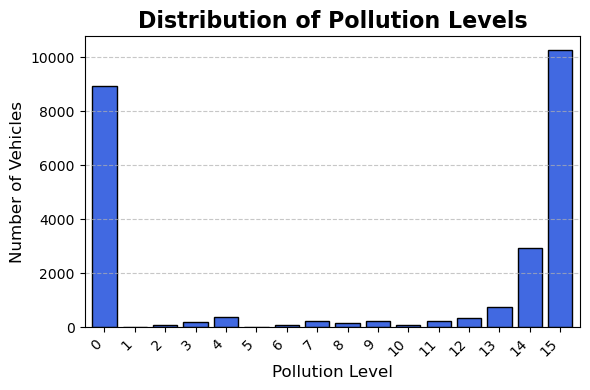

In [27]:
plot_distribution(df['kvutzat_zihum'], title='Distribution of Pollution Levels', xlabel='Pollution Level', ylabel='Number of Vehicles')

Due to the highly imbalanced distribution of pollution levels, where most vehicles are concentrated in levels 0 and 15, we decided to group the pollution levels into three categories (1, 2, 3) to achieve a more balanced and interpretable target variable

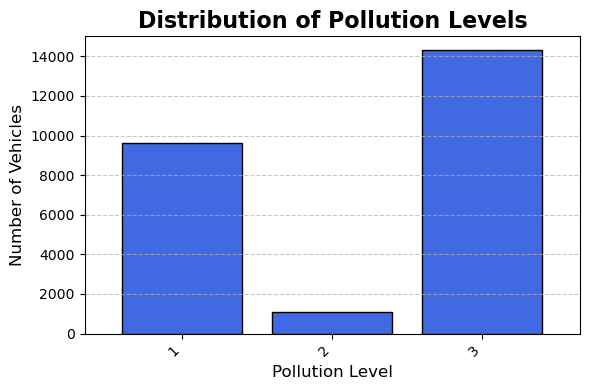

In [29]:
def categorize_pollution(value):
    if 0 <= value <= 4:
        return 1
    elif 5 <= value <= 11:
        return 2
    else:  
        return 3

# Creating new column with categories
df['kvutzat_zihum'] = df['kvutzat_zihum'].apply(categorize_pollution)
plot_distribution(df['kvutzat_zihum'], title='Distribution of Pollution Levels', xlabel='Pollution Level', ylabel='Number of Vehicles')

#### Numeric Variables Analysis

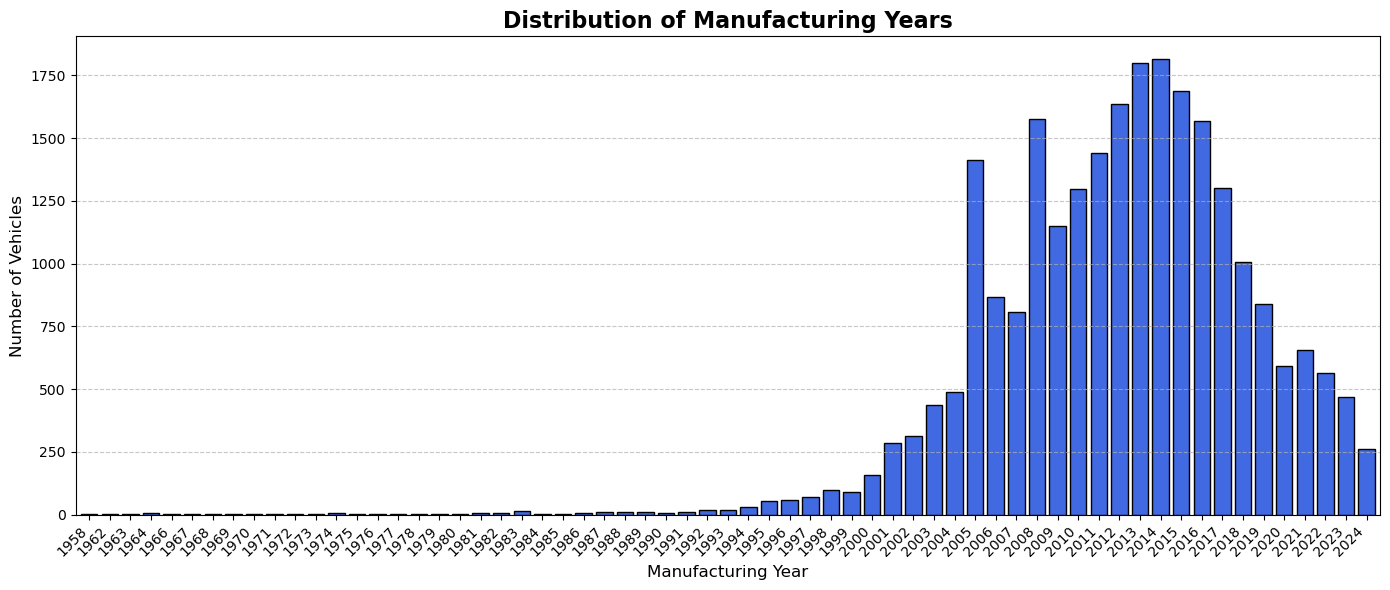

In [31]:
plot_distribution(df['shnat_yitzur'], title='Distribution of Manufacturing Years', xlabel='Manufacturing Year', ylabel='Number of Vehicles',figsize=(14, 6))


Based on the distribution of manufacturing years, we decided to remove vehicles manufactured before 1995 as they represent an extremely small sample size (less than 1% of the data). 

In [33]:
df = df[df['shnat_yitzur'] >= 1995]

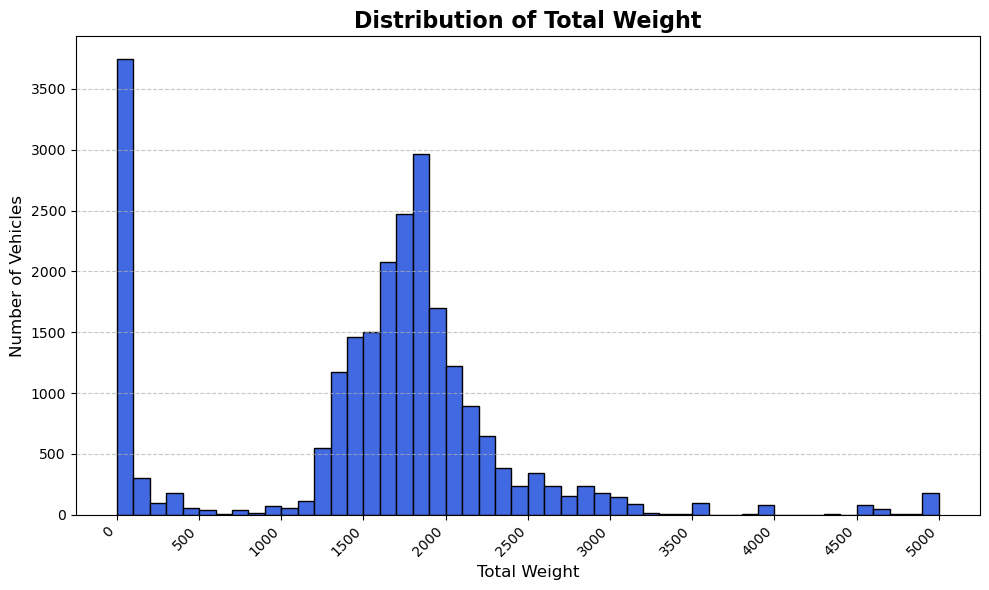

In [34]:
plot_weight_distribution(df['mishkal_kolel'], title='Distribution of Total Weight', xlabel='Total Weight', ylabel='Number of Vehicles', figsize=(10, 6), bins=50, max_value=5000)


In [35]:
# Basic analysis of weight values
weight_stats = {
    "Total records": len(df),
    "Zero weights": len(df[df['mishkal_kolel'] == 0]),
    "Zero weights percentage": (len(df[df['mishkal_kolel'] == 0]) / len(df)) * 100,
    "Min non-zero weight": df[df['mishkal_kolel'] > 0]['mishkal_kolel'].min(),
    "Max weight": df['mishkal_kolel'].max()
}

print("Weight Analysis:")
for key, value in weight_stats.items():
    if 'percentage' in key:
        print(f"{key}: {value:.2f}%")
    else:
        print(f"{key}: {value:,}")

Weight Analysis:
Total records: 24,803
Zero weights: 3,737
Zero weights percentage: 15.07%
Min non-zero weight: 1
Max weight: 80,000


Looking at the weight distribution, we can see that about 12% of vehicles have zero weight values. Since it's impossible for a vehicle to have no weight, we decided to convert these invalid values (zeros and unreasonably low weights) to missing values (NaN) for later handling in the preprocessing stage

In [37]:
df.loc[:, 'mishkal_kolel'] = df['mishkal_kolel'].replace(0, np.nan)

#### Category Variables Analysis

In [39]:
# Show basic statistics about vehicle types
n_unique = df['sug_rechev_nm'].nunique()
print(f"Number of unique vehicle types: {n_unique}")

Number of unique vehicle types: 85


With 83 unique vehicle types in our dataset, we'll group these into broader categories based on vehicle characteristics and weight to simplify our model and make it more robust

In [41]:
def categorize_vehicle(vehicle_type):

    if pd.isna(vehicle_type):
        return 'Unknown'
        
    categories = {
        'Private Vehicle': ['פרטי נוסעים', 'רכב שטח', 'מונית', 'פרטי רכב שדה',
                            'פרטי נוסעים 5 דלתות', 'פרטי נוסעים פתוח',
                            'פרטי נוסעים 3 דלתות', 'רכב זעיר'],
        
        'Heavy Truck': ['משא תומך', 'משא מערבל בטון', 'משא מגבה-נוע', 'נתמך',
                        'משא אשפה', 'משא מיכל', 'משא קירור מבוקר',
                        'משא סגור דופן הידראולית', 'משא בלתי אחוד סגור',
                        'משא רכין', 'משא בלתי אחוד פתוח', 'משא תומך עם מנוף',
                        'משא למיכלי גפמ'], 
        
        'Light Truck': ['משא פתוח', 'משא סגור', 'משא ב.אחוד', 'משא להובלת רכב',
                        'משא פתוח מנוף אחורי', 'משא פתוח תא נהג כפול',
                        'משא פתוח מנוף קדמי', 'משא הובלת משקאות',
                        'משא אחוד קירור בידוד', 'משא סגור קירור בידוד',
                        'משא ארגז חליפי'], 
        
        'Bus': ['אוטובוס', 'אוטובוס זעיר', 'אוטובוס זעיר צבורי',
                'אוטובוס צבורי בין-עירוני', 'אוטובוס צבורי עירוני',
                'אוטובוס צבורי לסיור', 'מונית-זוטובוס'],
        
        'Two-Wheeled': ['אופנוע', 'קטנוע', 'תלת אופנוע', 'טרקטורון',
                        'אופנוע להגשת עזרה ראשונה'],
        
        'Special Purpose': ['אמבולנס', 'עבודה', 'עבודה מיוחד', 'עבודה קידוח',
                            'עבודה מנוף רהיטים', 'עבודה משאבת בטון',
                            'מרכב אחוד', 'מרכב אחוד גג מוגבה',
                            'משא מיכל פורץ צנורות', 'דואר'],
        
        'Agricultural': ['טרקטור חקלאי', 'טרקטור רגיל', 'טרקטור משא',
                         'טרקטור משא חקלאי', 'טרקטורון חקלאי'],
        
        'Trailer': ['גרור פתוח', 'גרור סגור', 'גרור לסירה', 'גרור לחפצים',
                    'גרור לציוד ספורט', 'גרור עבודה-מיוחד', 'גרור סגור מגורים',
                    'גרור להובלת רכב', 'גרור רכין', 'גרור ארגז חליפי',
                    'גרור לסוסים', 'נתמך קירור מבוקר', 'נתמך ציוד חריג',
                    'גרור  לחפצים']  # Added here
    }
    
    # Check each category
    for category, patterns in categories.items():
        if any(pattern in str(vehicle_type) for pattern in patterns):
            return category
            
    return 'Other'

# הנחת נתוני DataFrame בשם df
# הוספת עמודת סיווג
df['vehicle_category'] = df['sug_rechev_nm'].apply(categorize_vehicle)

# הצגת התפלגות לפי קטגוריות
print("\nDistribution of new vehicle categories:")
print(df['vehicle_category'].value_counts())


Distribution of new vehicle categories:
Private Vehicle    19033
Two-Wheeled         2084
Special Purpose     1900
Light Truck          763
Heavy Truck          410
Bus                  395
Trailer              128
Agricultural          89
Other                  1
Name: vehicle_category, dtype: int64


In [42]:
df.drop('sug_rechev_nm', axis=1, inplace=True)

keep only the year from the 'bitul_dt' column:

In [44]:
df['bitul_dt'] = pd.to_datetime(df['bitul_dt']).dt.year

### Splitting Data into Training and Testing Sets

### *Target Variable Classification: Vehicle Pollution Group*

The target variable, Vehicle Pollution Group (kvutzat_zihum), categorizes vehicles into three levels of pollution: 3 for High Pollution, 2 for Medium Pollution, and 1 for Low Pollution.

This reclassification simplifies the original scale, grouping vehicles into broader categories that reflect their environmental impact. By consolidating the data into these meaningful groups, the model can better capture trends and patterns in pollution levels, enhancing interpretability and providing clearer insights.

In [47]:
# Define the target column and separate features and target
target_column = 'kvutzat_zihum'

# Separate the dataset into features (X) and target (y)
X = df.drop(columns=[target_column])
y = df[target_column]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Display the shapes of the train and test sets with clear formatting
print(f"Training Features (X_train): {X_train.shape[0]} rows, {X_train.shape[1]} columns")
print(f"Testing Features (X_test): {X_test.shape[0]} rows, {X_test.shape[1]} columns")
print(f"Training Target (y_train): {y_train.shape[0]} rows")
print(f"Testing Target (y_test): {y_test.shape[0]} rows")

Training Features (X_train): 17362 rows, 21 columns
Testing Features (X_test): 7441 rows, 21 columns
Training Target (y_train): 17362 rows
Testing Target (y_test): 7441 rows


### Missing Values

In [49]:
X_train.isnull().sum().sort_values()

tozeret_cd                  0
horaat_rishum               0
tzeva_rechev                0
baalut                      0
shnat_yitzur                0
ramat_eivzur_betihuty       0
vehicle_category            0
sug_rechev_cd               0
degem_nm                    0
tozeret_nm                  0
bitul_dt                    0
zmig_kidmi                 26
tozar_manoa               113
degem_manoa               113
sug_delek_nm              114
zmig_ahori               1173
mishkal_kolel            2611
degem_cd                 2627
kinuy_mishari            2697
ramat_gimur              3075
moed_aliya_lakvish       4154
dtype: int64

#### Moed Aliya Lakvish

In [51]:
calculate_and_print_equal_percentage(X_train,'moed_aliya_lakvish','shnat_yitzur')

Percentage of rows where 'moed_aliya_lakvish' equals 'shnat_yitzur': 100.00%


###### The column `'moed_aliya_lakvish'` was removed because 100% of its values are identical to those in `'shnat_yitzur'`. Keeping both columns would introduce redundancy without adding any new information.


In [53]:
X_train.drop('moed_aliya_lakvish', axis=1, inplace=True)
X_test.drop('moed_aliya_lakvish', axis=1, inplace=True)

#### zmig_ahori & 'zmig_kidmi'

In [55]:
calculate_and_print_equal_percentage(X_train,'zmig_kidmi','zmig_ahori')

Percentage of rows where 'zmig_kidmi' equals 'zmig_ahori': 89.97%


The function **fill_and_remove_tires** aims to fill missing values in the 'zmig_kidmi' column using values from the 'zmig_ahori' column, as 90% of the non-missing values in these columns are identical. This ensures consistency in the data while leveraging existing relationships. If missing values remain, they are filled with the most frequent value from the training set. After filling, 'zmig_ahori' is removed to avoid redundancy.


In [57]:
def fill_and_remove_tires(X_train, X_test):
    # Create an imputer to fill missing values with the most frequent value
    imputer = SimpleImputer(strategy='most_frequent')
    
    # Fill missing values in 'zmig_kidmi' in X_train with values from 'zmig_ahori'
    X_train['zmig_kidmi'] = X_train['zmig_kidmi'].fillna(X_train['zmig_ahori'])
    X_train['zmig_kidmi'] = imputer.fit_transform(X_train[['zmig_kidmi']]).ravel()
    
    # Fill missing values in 'zmig_kidmi' in X_test using the same approach
    X_test['zmig_kidmi'] = X_test['zmig_kidmi'].fillna(X_test['zmig_ahori'])
    X_test['zmig_kidmi'] = imputer.transform(X_test[['zmig_kidmi']]).ravel()
    
    return X_train, X_test

In [58]:
X_train, X_test = fill_and_remove_tires(X_train, X_test)

# Remove 'zmig_ahori' from train and test sets
X_train.drop(columns=['zmig_ahori'],inplace=True)
X_test.drop(columns=['zmig_ahori'],inplace=True)

#### Kinuy Mishari

In [60]:
def plot_distribution_custom(column_data, title='Distribution', xlabel='Category', ylabel='Count', figsize=(10, 6), bins=50, bar_width=0.8):
    plt.figure(figsize=figsize)

    plt.hist(column_data, bins=bins, color='royalblue', edgecolor='black', width=bar_width)

    plt.xticks(range(1, int(column_data.max()) + 1))
    
    plt.title(title, fontsize=16, fontweight='bold')
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(fontsize=10)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.gcf().set_facecolor('white')
    plt.tight_layout()
    plt.show()

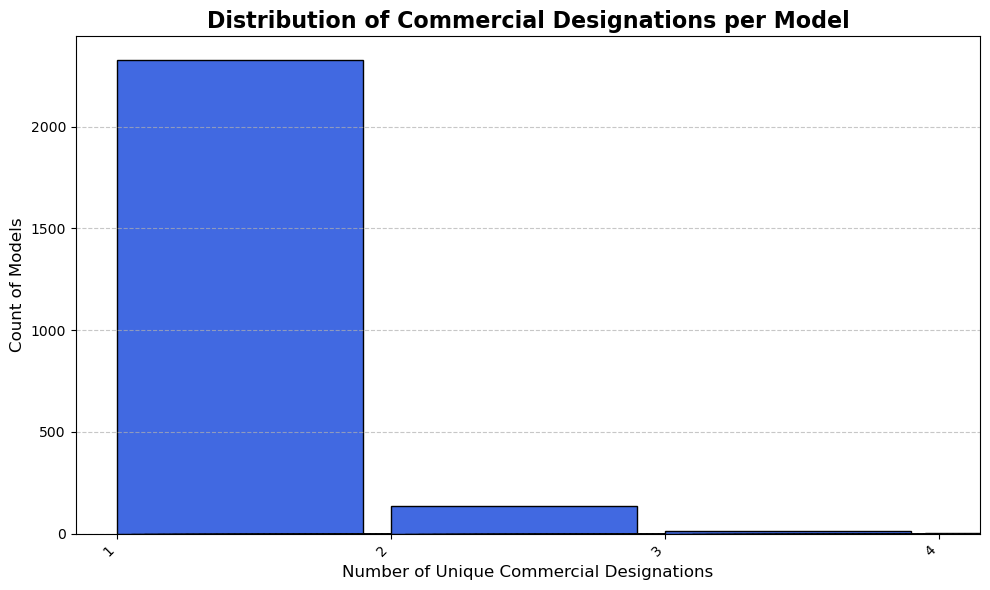

In [61]:
model_designation_train = X_train[X_train['kinuy_mishari'].notna()].groupby(['degem_nm'])['kinuy_mishari'].nunique()
plot_distribution_custom(model_designation_train, title='Distribution of Commercial Designations per Model', xlabel='Number of Unique Commercial Designations', ylabel='Count of Models', figsize=(10, 6), bins=60, bar_width=0.9)


##### Explanation for Missing Value Imputation

The graph shows most models (`degem_nm`) have a single dominant commercial designation (`kinuy_mishari`). Therefore, missing values were filled using the most frequent value per model, with the global mode used as a fallback for unknown or missing models.


In [63]:
def fill_kinuy_mishari(X_train, X_test):
    
    # Calculate the most frequent value (mode) per model in X_train
    most_frequent_by_model = X_train.groupby('degem_nm')['kinuy_mishari'].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
    
    # Global mode for 'kinuy_mishari' in X_train
    global_mode = X_train['kinuy_mishari'].mode().iloc[0]
    
    # Fill missing values in X_train
    X_train['kinuy_mishari'] = X_train['kinuy_mishari'].fillna(X_train['degem_nm'].map(most_frequent_by_model)).fillna(global_mode)
    
    # Fill missing values in X_test
    X_test['kinuy_mishari'] = X_test['kinuy_mishari'].fillna(X_test['degem_nm'].map(most_frequent_by_model)).fillna(global_mode)
    
    return X_train, X_test


In [64]:
X_train, X_test = fill_kinuy_mishari(X_train, X_test)

#### Ramat Gimur

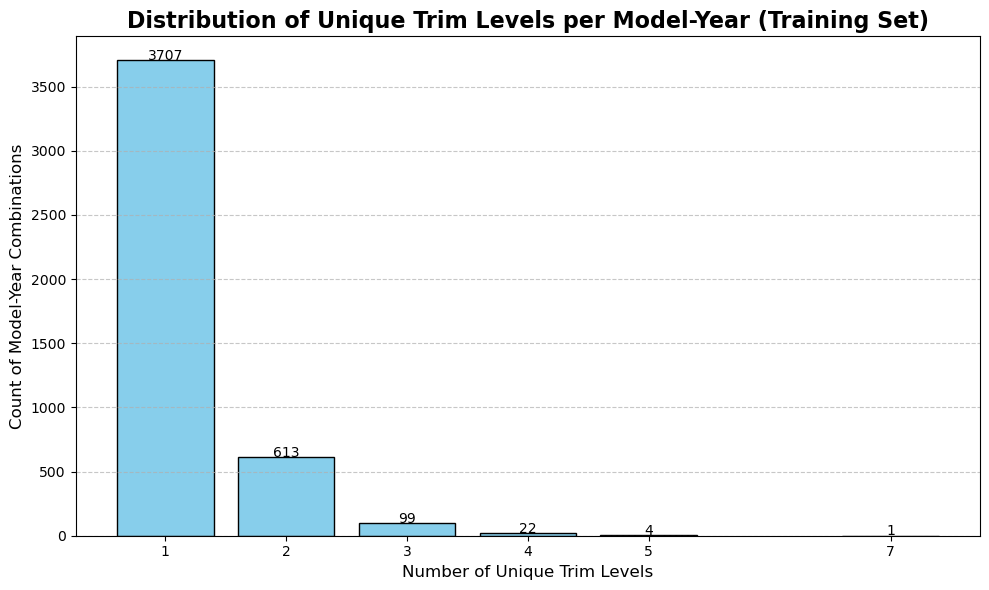

In [66]:
# Analyze trim levels by model and year in X_train
model_year_analysis_train = X_train[X_train['ramat_gimur'].notna()].groupby(['degem_nm', 'shnat_yitzur'])['ramat_gimur'].nunique().reset_index()
model_year_analysis_train.columns = ['Model', 'Year', 'Unique Trim Levels']

# Check the distribution 
distribution_train = model_year_analysis_train['Unique Trim Levels'].value_counts().sort_index()

# Visualization of the distribution for X_train
plt.figure(figsize=(10, 6))
bars = plt.bar(distribution_train.index, distribution_train.values, color='skyblue', edgecolor='black')
plt.title('Distribution of Unique Trim Levels per Model-Year (Training Set)', fontsize=16, weight='bold')
plt.xlabel('Number of Unique Trim Levels', fontsize=12)
plt.ylabel('Count of Model-Year Combinations', fontsize=12)
plt.xticks(distribution_train.index, fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on bars
for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1, int(bar.get_height()), ha='center', fontsize=10)

plt.tight_layout()
plt.show()


### Explanation for Missing Value Imputation in 'ramat_gimur'

The graph shows that most model-year combinations have a single dominant trim level (`ramat_gimur`). This indicates a strong relationship between `degem_nm` (model) and `shnat_yitzur` (year). Based on this, missing values in `ramat_gimur` were filled using the most frequent trim level for each model-year combination. For cases where no data exists for a specific combination, the global mode was used as a fallback.


In [68]:
def fill_trim_levels(X_train, X_test):

    # Calculate the global mode for 'ramat_gimur'
    global_mode = X_train['ramat_gimur'].mode().iloc[0]

    # Fill missing values in X_train by model-year and fallback to global mode
    X_train['ramat_gimur'] = X_train.groupby(['degem_nm', 'shnat_yitzur'])['ramat_gimur'].transform(
        lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else global_mode)
    )
    X_train['ramat_gimur'] = X_train['ramat_gimur'].fillna(global_mode)

    # Fill missing values in X_test based on X_train
    X_test['ramat_gimur'] = X_test.apply(
        lambda row: X_train[(X_train['degem_nm'] == row['degem_nm']) & 
                            (X_train['shnat_yitzur'] == row['shnat_yitzur'])]['ramat_gimur'].mode().iloc[0]
        if pd.isna(row['ramat_gimur']) and not X_train[(X_train['degem_nm'] == row['degem_nm']) & 
                                                       (X_train['shnat_yitzur'] == row['shnat_yitzur'])]['ramat_gimur'].mode().empty
        else (global_mode if pd.isna(row['ramat_gimur']) else row['ramat_gimur']),
        axis=1
    )
    
    return X_train, X_test


In [69]:
X_train, X_test = fill_trim_levels(X_train, X_test)

#### degem_manoa & tozar_manoa

In [71]:
# Group by 'degem_nm' and count unique values in 'degem_manoa' and 'tozar_manoa'
freq_analysis = X_train.groupby('degem_nm')[['degem_manoa', 'tozar_manoa']].nunique()

# Calculate the percentage of models with a single unique value in 'degem_manoa'
single_unique_degem_manoa = (freq_analysis['degem_manoa'] == 1).mean() * 100

# Calculate the percentage of models with a single unique value in 'tozar_manoa'
single_unique_tozar_manoa = (freq_analysis['tozar_manoa'] == 1).mean() * 100

# Print the results
print(f"Percentage of models with a single unique 'degem_manoa': {single_unique_degem_manoa:.2f}%")
print(f"Percentage of models with a single unique 'tozar_manoa': {single_unique_tozar_manoa:.2f}%")



Percentage of models with a single unique 'degem_manoa': 89.16%
Percentage of models with a single unique 'tozar_manoa': 88.51%


Based on the analysis, 88.61% of models (degem_nm) have a single unique value in degem_manoa, and 88.64% have a single unique value in tozar_manoa. This strong relationship suggests that missing values in these columns can be reliably filled using the most frequent value for each model (degem_nm).

In [73]:
def fill_missing_by_model(X_train, X_test, column_name, model_column='degem_nm'):

    # Step 1: Calculate the most frequent value (mode) for each model in X_train
    mode_mapping = X_train.groupby(model_column)[column_name].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
    
    # Step 2: Calculate the global mode as a fallback
    global_mode = X_train[column_name].mode().iloc[0]

    # Step 3: Fill missing values in X_train
    X_train[column_name] = X_train[column_name].fillna(
        X_train[model_column].map(mode_mapping).fillna(global_mode)
    )

    # Step 4: Fill missing values in X_test
    X_test[column_name] = X_test[column_name].fillna(
        X_test[model_column].map(mode_mapping).fillna(global_mode)
    )
    
    return X_train, X_test


In [74]:
# Fill missing values in 'degem_manoa'
X_train, X_test = fill_missing_by_model(X_train, X_test, 'degem_manoa')

# Fill missing values in 'tozar_manoa'
X_train, X_test = fill_missing_by_model(X_train, X_test, 'tozar_manoa')

#### degem_cd 

We removed the degem_cd column because it contains a fixed result for each value, which is already represented in the degem_nm column. The degem_cd column was redundant, as the necessary information is found in degem_nm.

In [77]:
X_train.drop(columns=['degem_cd'], inplace=True)
X_test.drop(columns=['degem_cd'], inplace=True)

#### Mishkal Kolel

We decided to fill missing values in the mishkal_kolel column using the median weight per vehicle_category from the training set. Missing values in the test set are filled based on the medians learned from the training data

In [80]:
def fill_missing_mishkal(X_train, X_test):
    median_by_category = X_train.groupby('vehicle_category')['mishkal_kolel'].median()
    
    X_train['mishkal_kolel'] = X_train.apply(
        lambda row: median_by_category[row['vehicle_category']] if pd.isna(row['mishkal_kolel']) else row['mishkal_kolel'], 
        axis=1
    )

    X_test['mishkal_kolel'] = X_test.apply(
        lambda row: median_by_category[row['vehicle_category']] if pd.isna(row['mishkal_kolel']) and row['vehicle_category'] in median_by_category else row['mishkal_kolel'], 
        axis=1
    )

    return X_train,X_test

X_train,X_test = fill_missing_mishkal(X_train,X_test)

#### Sug Delek nm

We decided to fill missing values in the sug_delek_nm column with the most frequent fuel type for each vehicle_category in the training set. If no mode was available, the overall most frequent fuel type was used. Missing values in the test set were filled based on the values learned from the training data

In [83]:
def fill_missing_fuel_type(X_train, X_test):
    
    most_frequent_fuel_by_category = X_train.groupby('vehicle_category')['sug_delek_nm'].agg(
        lambda x: x.mode()[0] if not x.mode().empty else X_train['sug_delek_nm'].mode()[0]
    )

    # fill missing values in the train set
    X_train['sug_delek_nm'] = X_train.apply(
        lambda row: most_frequent_fuel_by_category.get(row['vehicle_category'], most_frequent_fuel_by_category.mode()[0])
        if pd.isna(row['sug_delek_nm']) else row['sug_delek_nm'],
        axis=1
    )

    # fill missing values in the test set
    X_test['sug_delek_nm'] = X_test.apply(
        lambda row: most_frequent_fuel_by_category.get(row['vehicle_category'], most_frequent_fuel_by_category.mode()[0])
        if pd.isna(row['sug_delek_nm']) else row['sug_delek_nm'],
        axis=1
    )

    return X_train, X_test

X_train, X_test = fill_missing_fuel_type(X_train, X_test)


We created the DataImputer class to handle missing values in both numeric and categorical columns. The idea behind this approach is that for columns that didn't have missing values in the training set, we created an imputer to fill potential future missing values in the test set or when the dataset gets updated (e.g., through an API). The numeric columns are filled with their median, and categorical columns are filled with the mode value. This ensures that the model can handle missing data consistently, regardless of updates to the dataset.

In [85]:
class DataImputer:
    def __init__(self):
        self.numeric_imputer = {}
        self.categorical_imputer = {}

    def fit(self, X_train, numeric_columns, categorical_columns):
        # Fit numeric columns
        for column in numeric_columns:
            self.numeric_imputer[column] = X_train[column].median()

        # Fit categorical columns
        for column in categorical_columns:
            self.categorical_imputer[column] = X_train[column].mode().iloc[0]

    def transform(self, X, numeric_columns, categorical_columns):
        X_transformed = X.copy()

        # Fill numeric columns
        for column in numeric_columns:
            median = self.numeric_imputer[column]
            X_transformed[column] = X_transformed[column].fillna(median)

        # Fill categorical columns
        for column in categorical_columns:
            mode = self.categorical_imputer[column]
            X_transformed[column] = X_transformed[column].fillna(mode)

        return X_transformed


In [86]:
# Define columns
numeric_columns = ['ramat_eivzur_betihuty','horaat_rishum','shnat_yitzur','tozeret_cd','bitul_dt']
categorical_columns = ['baalut','degem_nm','tozeret_nm','tzeva_rechev','vehicle_category']

# Initialize the imputer
data_imputer = DataImputer()

# Fit on X_train
data_imputer.fit(X_train, numeric_columns, categorical_columns)

# Transform X_train and X_test
X_train = data_imputer.transform(X_train, numeric_columns, categorical_columns)
X_test = data_imputer.transform(X_test, numeric_columns, categorical_columns)


In [87]:
X_train.isnull().sum().sort_values()

tozeret_cd               0
horaat_rishum            0
sug_delek_nm             0
zmig_kidmi               0
tzeva_rechev             0
baalut                   0
shnat_yitzur             0
ramat_eivzur_betihuty    0
ramat_gimur              0
mishkal_kolel            0
degem_manoa              0
tozar_manoa              0
bitul_dt                 0
sug_rechev_cd            0
degem_nm                 0
tozeret_nm               0
kinuy_mishari            0
vehicle_category         0
dtype: int64

In [88]:
X_test.isnull().sum().sort_values()

tozeret_cd               0
horaat_rishum            0
sug_delek_nm             0
zmig_kidmi               0
tzeva_rechev             0
baalut                   0
shnat_yitzur             0
ramat_eivzur_betihuty    0
ramat_gimur              0
mishkal_kolel            0
degem_manoa              0
tozar_manoa              0
bitul_dt                 0
sug_rechev_cd            0
degem_nm                 0
tozeret_nm               0
kinuy_mishari            0
vehicle_category         0
dtype: int64

# ----------------------------------------------------------------------------------------

### Distribution of Mishkal Kolel by Vehicle Category


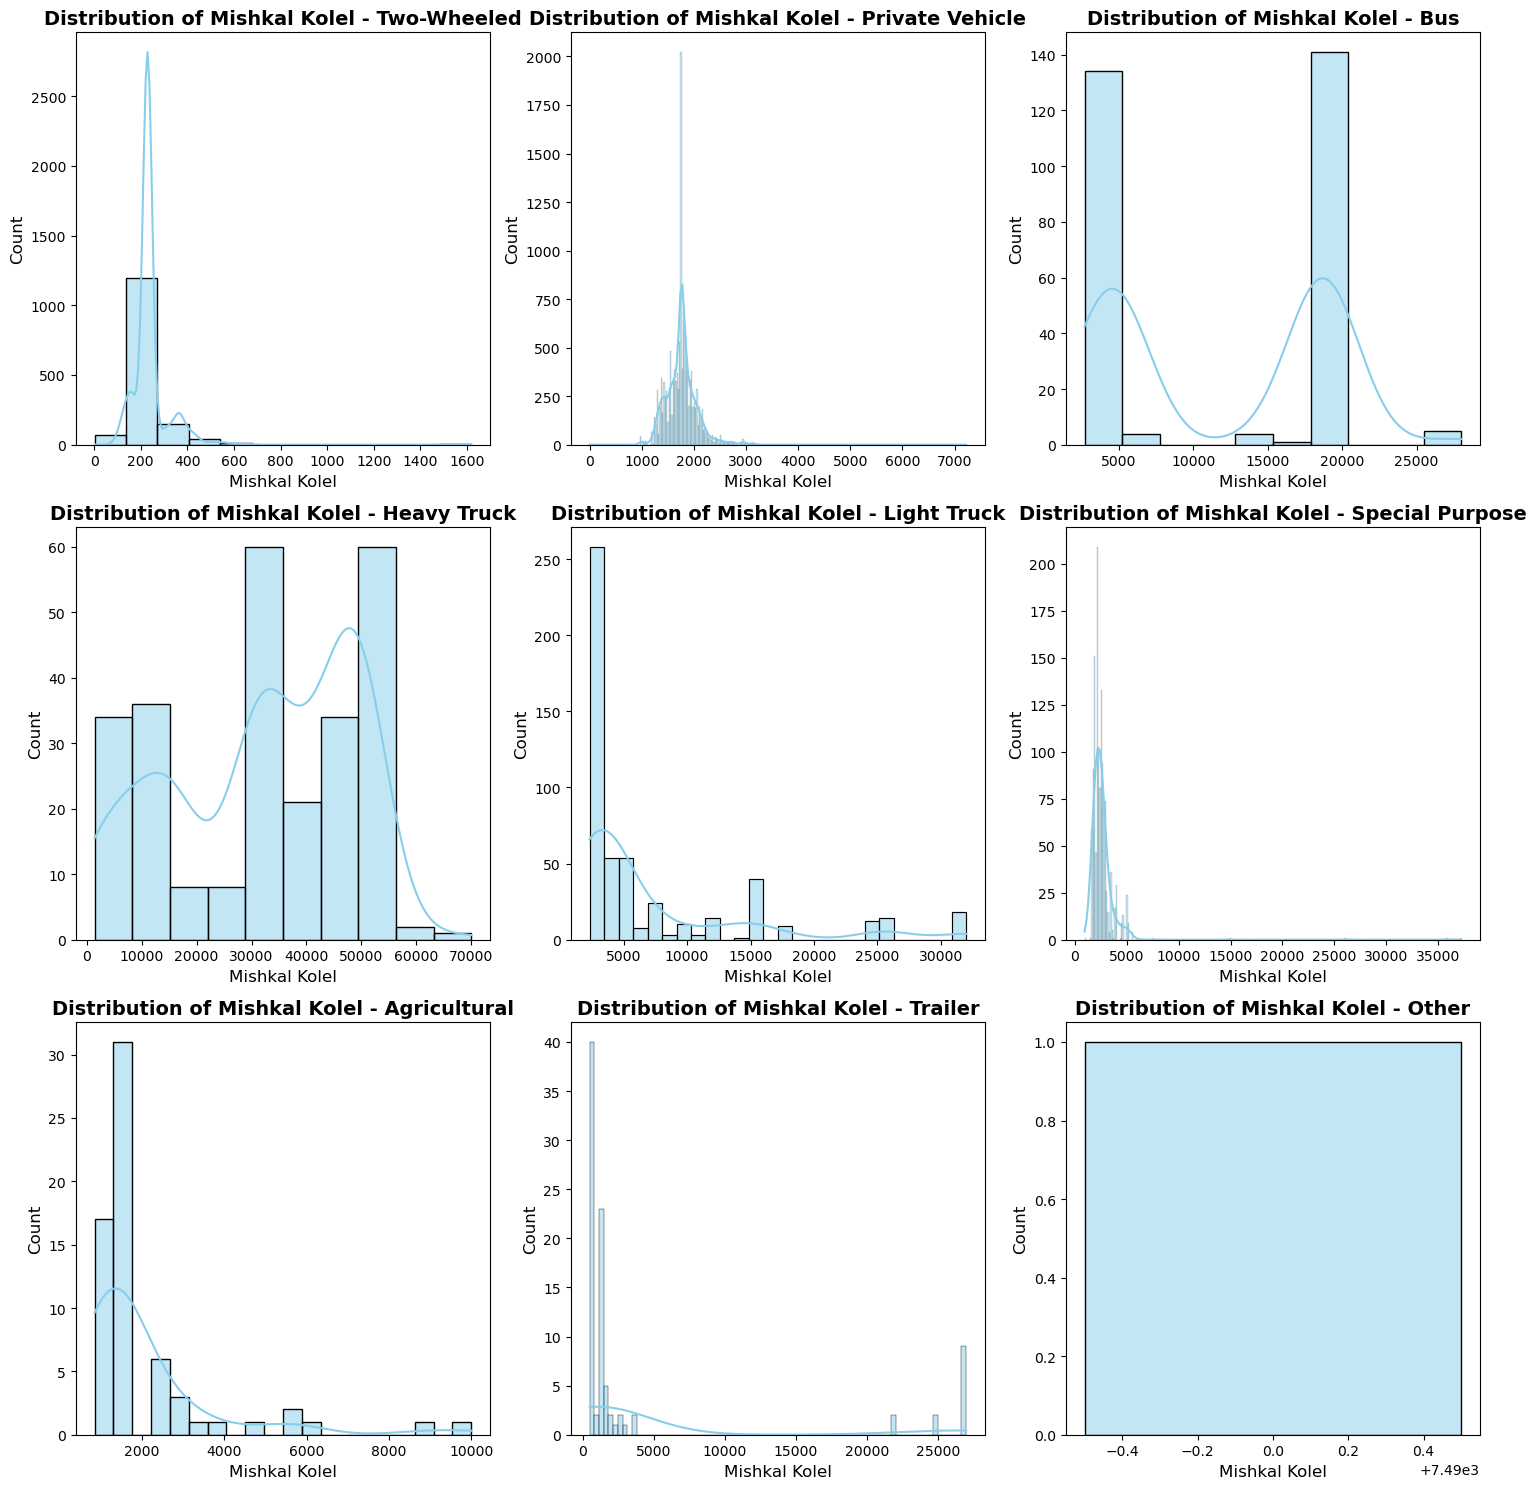

In [91]:
vehicle_categories = X_train['vehicle_category'].unique()

num_rows = len(vehicle_categories) // 3 + (1 if len(vehicle_categories) % 3 else 0)
fig, axs = plt.subplots(num_rows, 3, figsize=(15, num_rows * 5)) 

for i, category in enumerate(vehicle_categories):
    ax = axs[i // 3, i % 3]  
    sns.histplot(data=X_train[X_train['vehicle_category'] == category], x="mishkal_kolel", kde=True, ax=ax, color='skyblue', edgecolor='black')
    ax.set_title(f'Distribution of Mishkal Kolel - {category}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Mishkal Kolel', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)

for i in range(len(vehicle_categories), num_rows * 3):
    fig.delaxes(axs.flatten()[i])

plt.tight_layout()
plt.show()

The distribution of "Mishkal Kolel" varies significantly across different vehicle categories. For example, lighter vehicles like buses and light trucks show a more concentrated distribution with lower weights, while heavier vehicles like trailers and agricultural vehicles display a wider range of values, including extreme outliers.

Given these variations and the presence of outliers, we applied the Interquartile Range (IQR) method to detect and handle extreme values. This method helps ensure the model's accuracy by focusing on more relevant data points.

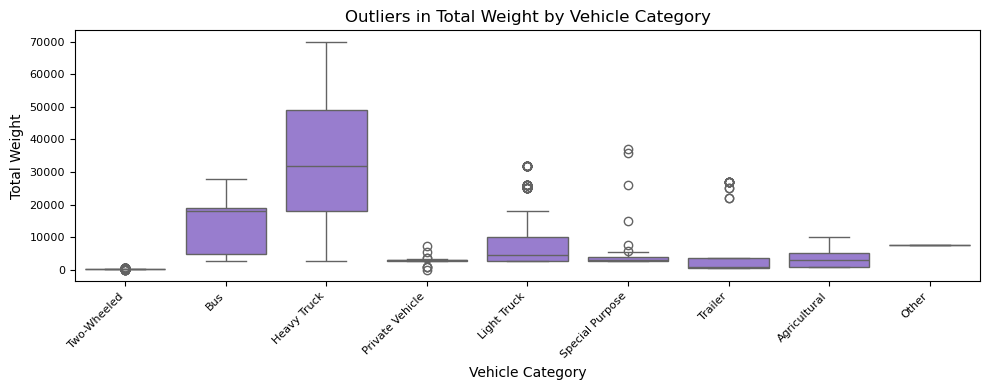

In [93]:
def plot_outliers_boxplot(X_train, weight_column, category_column):

    Q1 = X_train[weight_column].quantile(0.25)
    Q3 = X_train[weight_column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = X_train[(X_train[weight_column] < lower_bound) | (X_train[weight_column] > upper_bound)]


    plt.figure(figsize=(10, 4))  
    sns.boxplot(
        data=outliers,
        x=category_column,
        y=weight_column,
        color="mediumpurple"
    )
    plt.title("Outliers in Total Weight by Vehicle Category", fontsize=12, color="black")
    plt.xlabel("Vehicle Category", fontsize=10, color="black")
    plt.ylabel("Total Weight", fontsize=10, color="black")
    plt.xticks(rotation=45, ha='right', fontsize=8, color="black")
    plt.yticks(fontsize=8, color="black")
    plt.tight_layout()
    plt.show()


plot_outliers_boxplot(X_train, weight_column='mishkal_kolel', category_column='vehicle_category')


We handled outliers in the "Mishkal Kolel" (total weight) column by applying domain-specific absolute limits for each vehicle category. For values within the allowed range, we used the Interquartile Range (IQR) method to identify and clip extreme values. This was done for both the training and testing datasets. The outliers were adjusted based on the vehicle category, ensuring the weights remain within realistic bounds, thus improving the quality of the data for model training and evaluation.

In [95]:
def handle_outliers_combined(train_data, test_data):
    # Define absolute limits based on domain knowledge
    absolute_limits = {
        'Private Vehicle': (500, 5000),
        'Two-Wheeled': (80, 1200),
        'Light Truck': (1000, 15000),
        'Heavy Truck': (5000, 80000),
        'Bus': (2500, 30000),
        'Special Purpose': (1000, 20000),
        'Trailer': (400, 15000),
        'Agricultural': (800, 20000)
    }
    
    train_clean = train_data.copy()
    test_clean = test_data.copy()
    outliers_summary = {}
    
    for category in train_data['vehicle_category'].unique():
        # Check if the category is in absolute_limits
        if category not in absolute_limits:
            print(f"Warning: Category '{category}' not found in absolute_limits. Skipping...")
            continue  # Skip this category if not defined
        
        # Get absolute limits
        min_allowed, max_allowed = absolute_limits[category]
        
        # Calculate statistical limits from data within absolute bounds
        cat_data = train_data[
            (train_data['vehicle_category'] == category) & 
            (train_data['mishkal_kolel'].between(min_allowed, max_allowed))
        ]['mishkal_kolel']
        
        Q1 = cat_data.quantile(0.25)
        Q3 = cat_data.quantile(0.75)
        IQR = Q3 - Q1
        lower = max(min_allowed, Q1 - 1.5 * IQR)
        upper = min(max_allowed, Q3 + 1.5 * IQR)
        
        # Store original values for comparison
        original_values = train_clean[train_clean['vehicle_category'] == category]['mishkal_kolel'].copy()
        
        # Clip values in train set
        mask = (train_clean['vehicle_category'] == category)
        train_clean.loc[mask, 'mishkal_kolel'] = train_clean.loc[mask, 'mishkal_kolel'].clip(lower=lower, upper=upper)
        
        # Clip values in test set
        mask = (test_clean['vehicle_category'] == category)
        test_clean.loc[mask, 'mishkal_kolel'] = test_clean.loc[mask, 'mishkal_kolel'].clip(lower=lower, upper=upper)
        
        # Calculate how many values were modified
        modified_count = sum(original_values != train_clean[train_clean['vehicle_category'] == category]['mishkal_kolel'])
        total_count = len(original_values)
        
        # Store results
        outliers_summary[category] = {
            'lower_bound': lower,
            'upper_bound': upper,
            'values_modified': modified_count,
            'modification_percentage': (modified_count / total_count * 100) if total_count > 0 else 0
        }
    
    return train_clean, test_clean


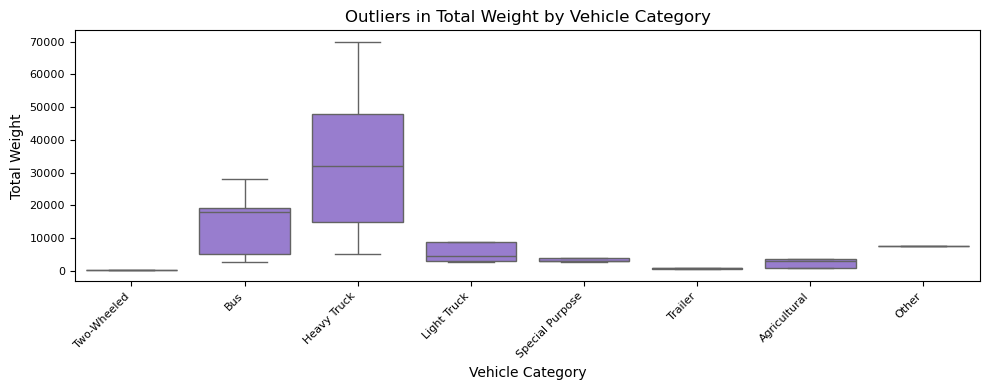

In [96]:
# Apply the outlier handling function to both train and test sets
X_train,X_test = handle_outliers_combined(X_train, X_test)

plot_outliers_boxplot(X_train, weight_column='mishkal_kolel', category_column='vehicle_category')

#### Multicollinearity

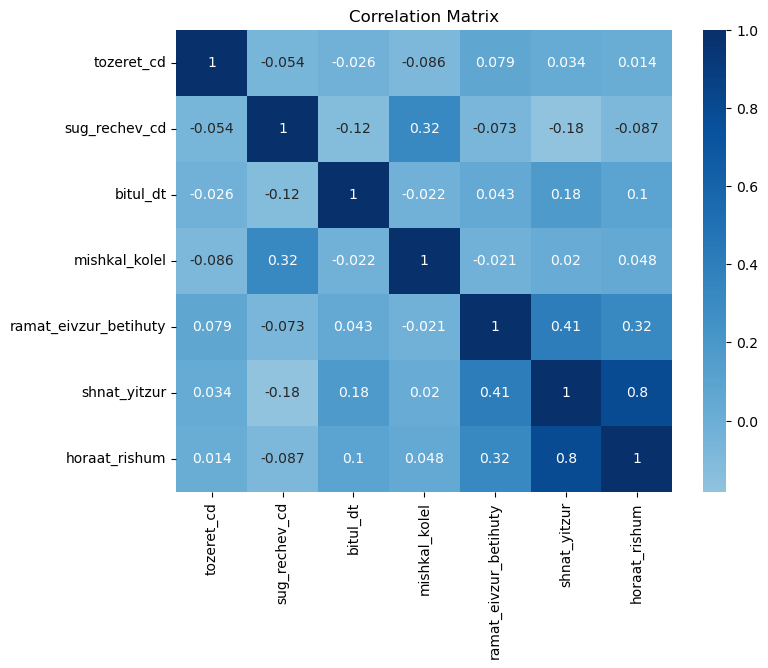

In [98]:
# Get numeric columns
numeric_cols = X_train.select_dtypes(include=['float64', 'int64']).columns

# Calculate correlation matrix
correlation_matrix = X_train[numeric_cols].corr()

# Visualize correlations
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='Blues', center=0)
plt.title('Correlation Matrix')
plt.show()

We performed a multicollinearity check using a correlation heatmap because some of our models, particularly Logistic Regression, are sensitive to highly correlated features. The analysis revealed a strong correlation (0.79) between manufacturing year ('shnat_yitzur') and registration directive ('horaat_rishum'). As these features contain redundant information, we decided to remove 'horaat_rishum' while keeping 'shnat_yitzur' as it's more intuitive and interpretable for our pollution level prediction

In [100]:
X_train = X_train.drop('horaat_rishum', axis=1)
X_test = X_test.drop('horaat_rishum', axis=1)

### Feature Selection

Selected Features (Top all):
['tozeret_cd', 'sug_rechev_cd', 'bitul_dt', 'mishkal_kolel', 'ramat_eivzur_betihuty', 'shnat_yitzur']


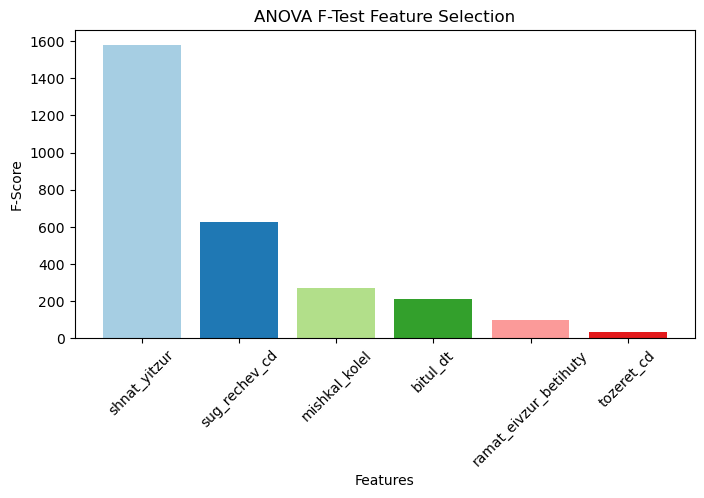

In [102]:
numerical_columns = X_train.select_dtypes(include=['float64', 'int64']).columns
anova_results = anova_f_test_feature_selection(X_train[numerical_columns], y_train)

Based on the ANOVA F-Test feature selection results, the feature "tozeret_cd" has a significantly low F-Score and does not contribute much to predicting the target variable. Therefore, it should be removed from the model to improve its performance and prevent unnecessary complexity.

In [104]:
X_train = X_train.drop('tozeret_cd', axis=1)
X_test = X_test.drop('tozeret_cd', axis=1)

In [105]:

def process_data(X_train, X_test):

    # Columns for each transformation
    binary_cols = ['degem_manoa', 'degem_nm', 'kinuy_mishari', 
                   'ramat_gimur', 'sug_delek_nm', 'tozar_manoa', 
                   'tozeret_nm', 'tzeva_rechev', 'vehicle_category', 'zmig_kidmi','baalut']
    ordinal_cols = ['ramat_eivzur_betihuty']
    standard_cols = ['bitul_dt', 'mishkal_kolel', 'shnat_yitzur', 'sug_rechev_cd']

    # Combine X_train and X_test to ensure all categories are present in training
    combined_X = pd.concat([X_train[binary_cols], X_test[binary_cols]])
    
    # Initialize transformers
    binary_encoder = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')
    ordinal_encoder = OrdinalEncoder()
    scaler = StandardScaler()

    # Apply Binary Encoding
    binary_encoder.fit(combined_X)
    X_train_binary = pd.DataFrame(binary_encoder.transform(X_train[binary_cols]), 
                                  columns=binary_encoder.get_feature_names_out(binary_cols), 
                                  index=X_train.index)
    X_test_binary = pd.DataFrame(binary_encoder.transform(X_test[binary_cols]), 
                                 columns=binary_encoder.get_feature_names_out(binary_cols), 
                                 index=X_test.index)

    # Apply Ordinal Encoding
    X_train_ordinal = pd.DataFrame(ordinal_encoder.fit_transform(X_train[ordinal_cols]), 
                                   columns=ordinal_cols, index=X_train.index)
    X_test_ordinal = pd.DataFrame(ordinal_encoder.transform(X_test[ordinal_cols]), 
                                  columns=ordinal_cols, index=X_test.index)

    # Apply Standard Scaling
    X_train_standard = pd.DataFrame(scaler.fit_transform(X_train[standard_cols]), 
                                    columns=standard_cols, index=X_train.index)
    X_test_standard = pd.DataFrame(scaler.transform(X_test[standard_cols]), 
                                   columns=standard_cols, index=X_test.index)

    # Drop original columns and concatenate transformed data
    X_train = pd.concat([X_train.drop(columns=binary_cols + ordinal_cols + standard_cols),
                         X_train_binary, X_train_ordinal, X_train_standard], axis=1)
    X_test = pd.concat([X_test.drop(columns=binary_cols + ordinal_cols + standard_cols),
                        X_test_binary, X_test_ordinal, X_test_standard], axis=1)
    
    print("All data has been successfully encoded and scaled.")
    return X_train, X_test

In [106]:
X_train, X_test = process_data(X_train, X_test)

All data has been successfully encoded and scaled.


In [107]:
# Display the shape of X_train after processing
print(f"Shape of X_train after processing: {X_train.shape}")
# Display the shape of X_train after processing
print(f"Shape of X_test after processing: {X_test.shape}")

Shape of X_train after processing: (17362, 10678)
Shape of X_test after processing: (7441, 10678)


# ----------------------------------------------------------------------------------------

## Class Imbalance

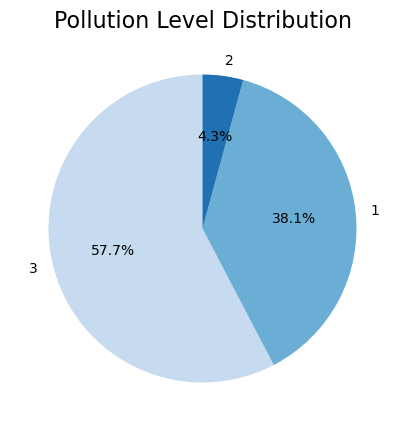

In [110]:
plt.figure(figsize=(5,5))
y_train.value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Blues', 3), legend=False)

plt.title('Pollution Level Distribution', fontsize=16)
plt.ylabel('')
plt.show()

The pie chart shows an imbalance in the target variable "Pollution Level," with class 3 (High Pollution) comprising the majority, while class 2 (Medium Pollution) and class 1 (Low Pollution) are underrepresented. To address this class imbalance, we chose to use the SMOTE (Synthetic Minority Over-sampling Technique) method. SMOTE generates synthetic samples for the minority classes by interpolating between existing data points, thereby balancing the class distribution and improving model training.

Original class distribution: 3    10011
1     6611
2      740
Name: kvutzat_zihum, dtype: int64
Resampled class distribution: 1    10011
3    10011
2    10011
Name: kvutzat_zihum, dtype: int64


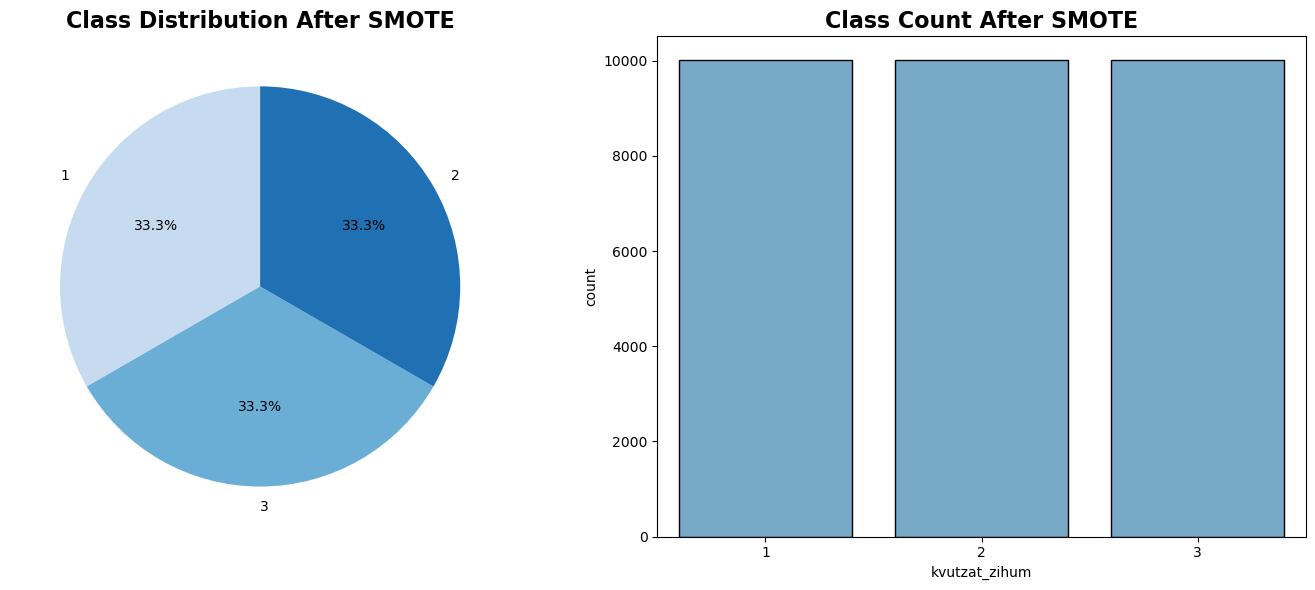

In [112]:
X_resampled, y_resampled = apply_smote(X_train, y_train)

In [113]:
X_train, y_train=X_resampled, y_resampled

## Features importance 

The function uses a Random Forest model to calculate feature importances, filtering out features with low importance scores based on a specified threshold. It then returns the most important features for further model training, helping to reduce dimensionality and improve model performance.

In [116]:
def filter_features_by_importance_relative(X_train, X_test, model, threshold=0.001):
    
    # Get feature importances
    importances = model.feature_importances_
    
    # Create a DataFrame for features and their importance
    feature_names = X_train.columns
    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    })

    # Add relative importance as a percentage of 100%
    importance_df["Relative Importance (%)"] = (importance_df["Importance"] / importance_df["Importance"].sum()) * 100

    # Filter features with importance > threshold
    filtered_features = importance_df[importance_df["Importance"] > threshold].sort_values(by="Importance", ascending=False)

    # Save the most important features in a variable
    most_important_features = filtered_features["Feature"].tolist()

    # Display number of remaining features
    num_features = len(filtered_features)
    print(f"Number of features with importance > {threshold}: {num_features}")

    # Filter X_train and X_test to include only these features
    X_train_filtered = X_train[most_important_features]
    X_test_filtered = X_test[most_important_features]

    return X_train_filtered, X_test_filtered, num_features,most_important_features


rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

X_train_filtered, X_test_filtered, num_features,most_important_features = filter_features_by_importance_relative(X_train, X_test, rf, threshold=0.001)

print(f"Filtered X_train shape: {X_train_filtered.shape}")
print(f"Filtered X_test shape: {X_test_filtered.shape}")

Number of features with importance > 0.001: 172
Filtered X_train shape: (30033, 172)
Filtered X_test shape: (7441, 172)


## models

In [118]:

# Plot Confusion Matrix
def plot_confusion_matrix(ax, y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f'Confusion Matrix - {model_name}')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

# Check for Overfitting
def plot_overfitting(ax, model, X_train, X_test, y_train, y_test, model_name):
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)
    difference = abs(train_score - test_score)
    
    ax.bar(['Train', 'Test'], [train_score, test_score], color=['blue', 'green'])
    ax.set_ylim(0, 1)
    ax.set_title(f'Overfitting Check - {model_name}')
    ax.text(0, train_score + 0.02, f"{train_score:.3f}", ha='center', fontsize=10)
    ax.text(1, test_score + 0.02, f"{test_score:.3f}", ha='center', fontsize=10)
    ax.set_ylabel('Score')

# Plot Learning Curve
def plot_learning_curve(ax, model, X_train, y_train, model_name, sample_size=5000):
    X_train_sample = X_train.sample(n=sample_size, random_state=42)
    y_train_sample = y_train.loc[X_train_sample.index]
    
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_train_sample, y_train_sample, cv=5, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10)
    )
    
    ax.plot(train_sizes, np.mean(train_scores, axis=1), label='Training score')
    ax.plot(train_sizes, np.mean(val_scores, axis=1), label='Validation score')
    ax.set_title(f'Learning Curve - {model_name}')
    ax.set_xlabel('Training Examples')
    ax.set_ylabel('Score')
    ax.legend(loc='best')
    ax.grid(True)

# Train and Evaluate Model
def train_evaluate_model(model, param_grid, X_train, X_test, y_train, y_test, model_name):
    # Grid Search
    grid_search = GridSearchCV(model, param_grid, cv=3, scoring='f1_weighted', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    
    # Best model predictions
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    
    # Calculate metrics
    results = {
        'Model': model_name,
        'Precision': precision_score(y_test, y_pred, average='weighted'),
        'Recall': recall_score(y_test, y_pred, average='weighted'),
        'F1-score': f1_score(y_test, y_pred, average='weighted'),
        'Best Parameters': grid_search.best_params_
    }
    
    # Create plots
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    plot_confusion_matrix(axes[0], y_test, y_pred, model_name)
    plot_overfitting(axes[1], best_model, X_train, X_test, y_train, y_test, model_name)
    plot_learning_curve(axes[2], best_model, X_train, y_train, model_name)
    plt.tight_layout()
    plt.show()
    
    return pd.DataFrame([results]), best_model

### SVM Model

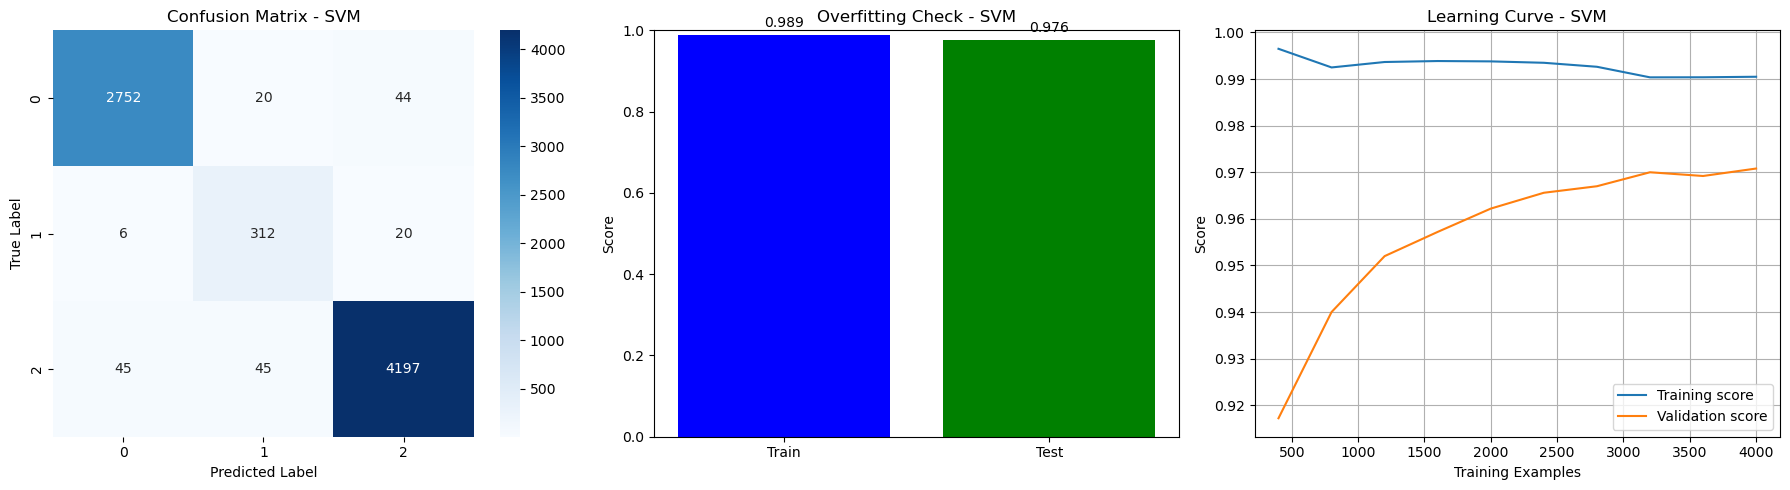


SVM Results:
  Model  Precision   Recall  F1-score             Best Parameters
0   SVM   0.976629  0.97581  0.976094  {'C': 10, 'kernel': 'rbf'}


In [120]:
svm_params = {
    'C': [10],
    'kernel': ['rbf']
}

svm_results, svm_model = train_evaluate_model(
    SVC(probability=True, random_state=42),
    svm_params,
    X_train_filtered, X_test_filtered,
    y_train, y_test,
    "SVM"
)

if svm_results is not None:
    print("\nSVM Results:")
    print(svm_results)

The SVM model demonstrates strong performance with minimal overfitting (1.8% difference between train and test scores). The learning curves show stable training performance and consistently improving cross-validation scores, indicating good generalization ability. The confusion matrix reveals high accuracy across all categories, particularly in predicting categories 0 and 2, though with slightly lower precision for category 1

### Random Forest Model

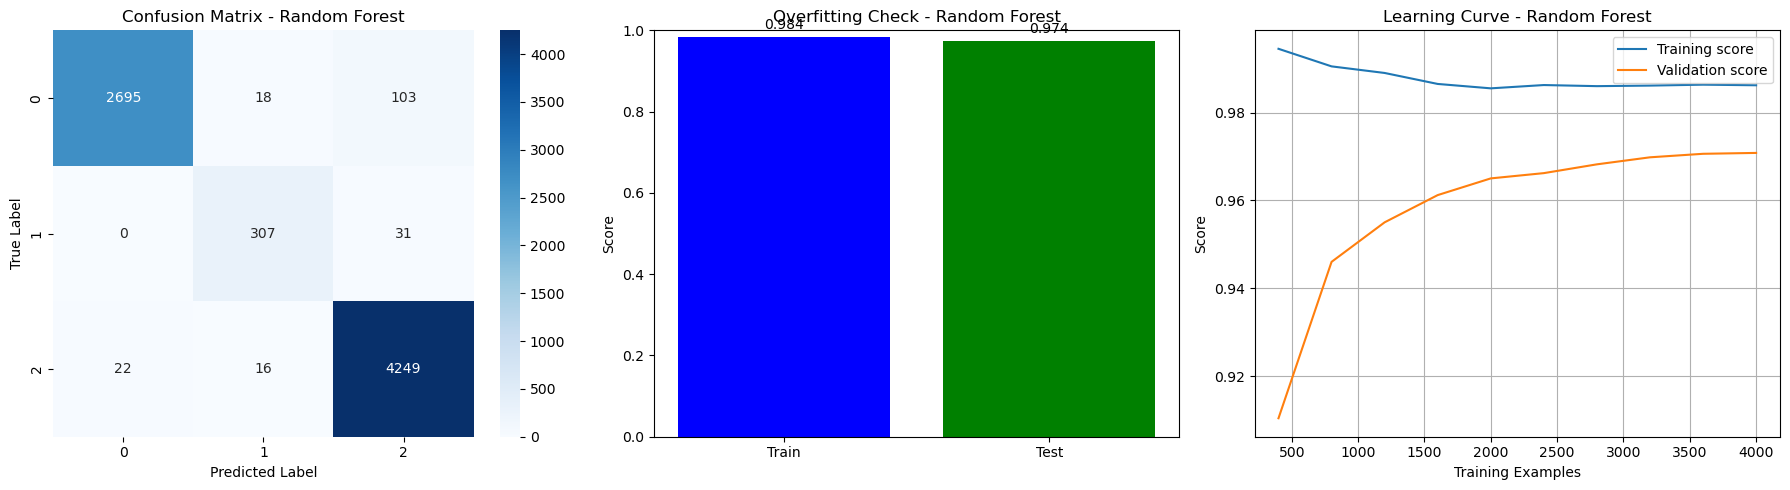


Random Forest Results:
           Model  Precision    Recall  F1-score  \
0  Random Forest   0.974793  0.974466  0.974441   

                          Best Parameters  
0  {'max_depth': 20, 'n_estimators': 100}  


In [123]:
rf_params = {
    'n_estimators': [100],
    'max_depth': [20]
}

# Train and Evaluate Random Forest Model
rf_results, rf_model = train_evaluate_model(
    RandomForestClassifier(random_state=42),
    rf_params,
    X_train_filtered, X_test_filtered,
    y_train, y_test,
    "Random Forest"
)

if rf_results is not None:
    print("\nRandom Forest Results:")
    print(rf_results)

The Random Forest model shows excellent performance with minimal overfitting (1% difference between train and test scores). The learning curves demonstrate stable and high performance, with the cross-validation score steadily improving and approaching the training score. The confusion matrix shows strong predictive power, particularly for categories 0 and 2, with high accuracy in identifying pollution levels

### KNN Model

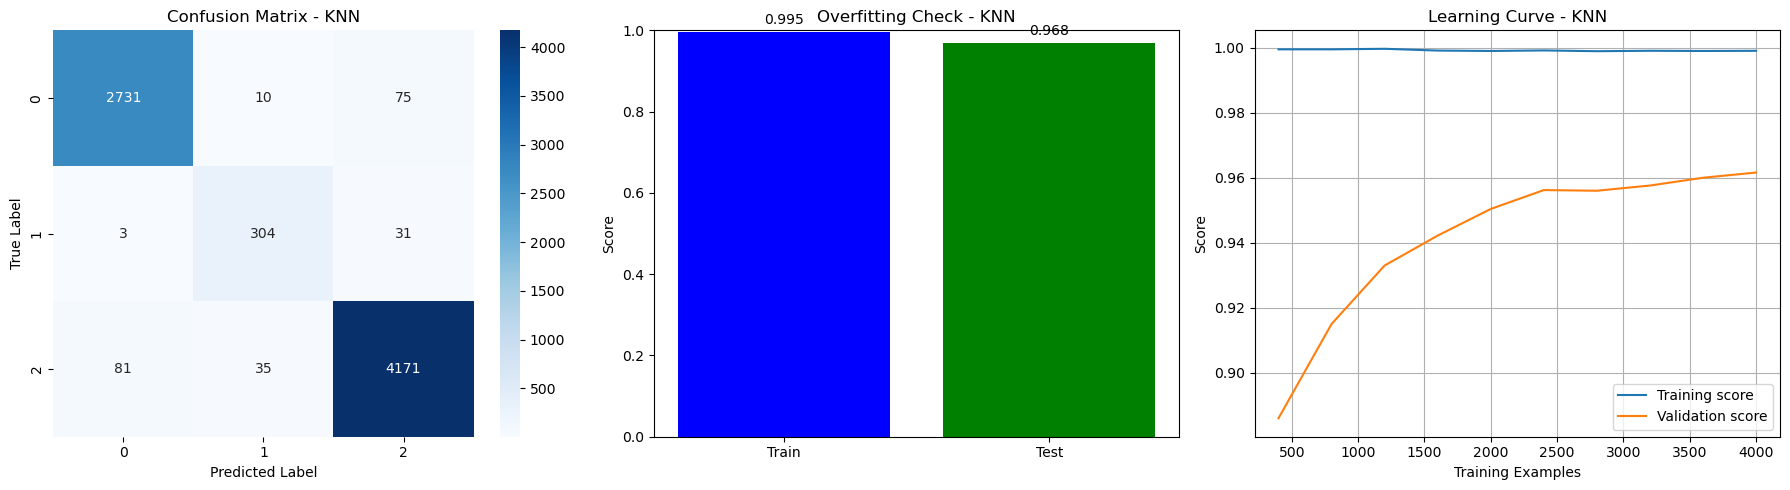


KNN Results:
  Model  Precision    Recall  F1-score  \
0   KNN   0.968572  0.968418  0.968484   

                             Best Parameters  
0  {'n_neighbors': 3, 'weights': 'distance'}  


In [126]:
# KNN Parameters
knn_params = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance']
}

# Train and Evaluate KNN Model
knn_results, knn_model = train_evaluate_model(
    KNeighborsClassifier(),
    knn_params,
    X_train_filtered, X_test_filtered,
    y_train, y_test,
    "KNN"
)

if knn_results is not None:
    print("\nKNN Results:")
    print(knn_results)

The KNN model shows signs of overfitting with a 2.9% difference between train and test scores. The learning curves reveal a significant gap between training and cross-validation performance, with the training score remaining consistently high while the cross-validation score improves more gradually. Though the confusion matrix shows good accuracy overall, the model's performance is slightly lower than RF and SVM, particularly in misclassifying more cases in category 2

### Logistic Regression Model

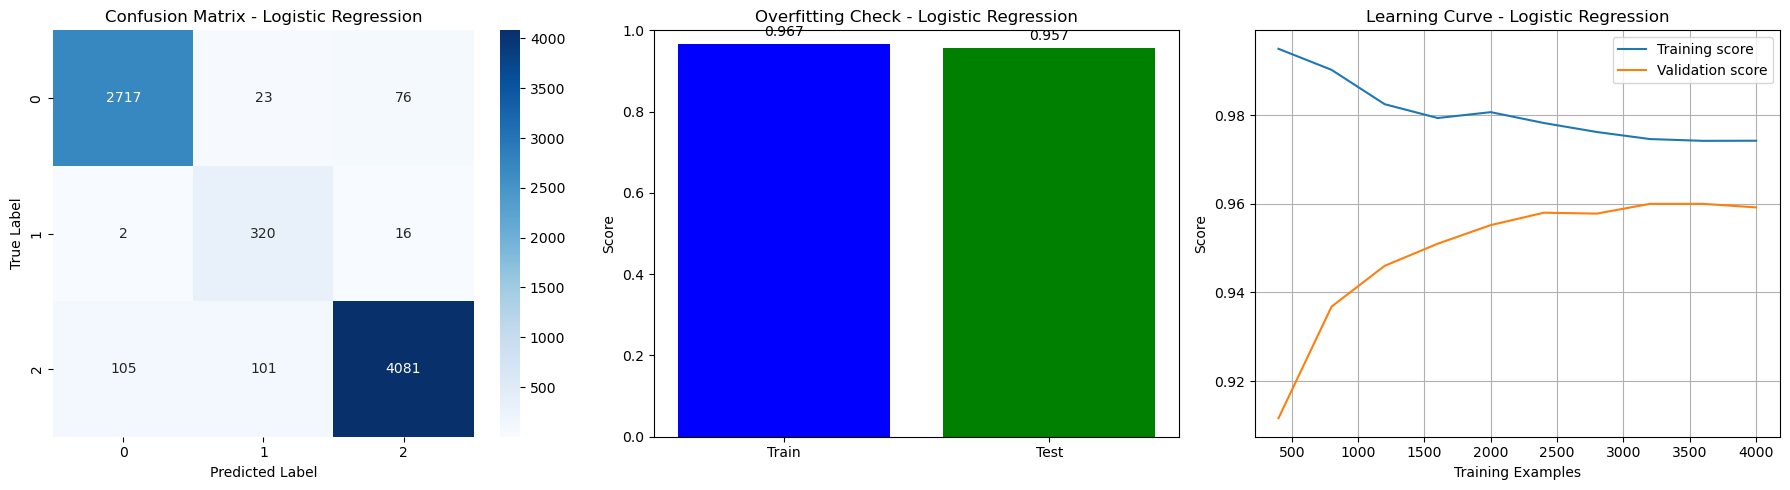


Logistic Regression Results:
                 Model  Precision    Recall  F1-score  \
0  Logistic Regression   0.960273  0.956592  0.957635   

               Best Parameters  
0  {'C': 10, 'max_iter': 1000}  


In [129]:
# Logistic Regression Parameters
lr_params = {
    'C': [0.1, 1, 10],
    'max_iter': [1000]
}

# Train and Evaluate Logistic Regression Model
lr_results, lr_model = train_evaluate_model(
    LogisticRegression(random_state=42),
    lr_params,
    X_train_filtered, X_test_filtered,
    y_train, y_test,
    "Logistic Regression"
)

if lr_results is not None:
    print("\nLogistic Regression Results:")
    print(lr_results)

The Logistic Regression model shows good performance with minimal overfitting (1.4% difference between train and test scores). The learning curves indicate that while the training score gradually decreases, the cross-validation score steadily improves and stabilizes. The confusion matrix shows decent performance across categories but with more misclassifications in category 2 compared to RF and SVM, suggesting it handles complex patterns less effectively than the more sophisticated models."

### Gradient Boosting Model

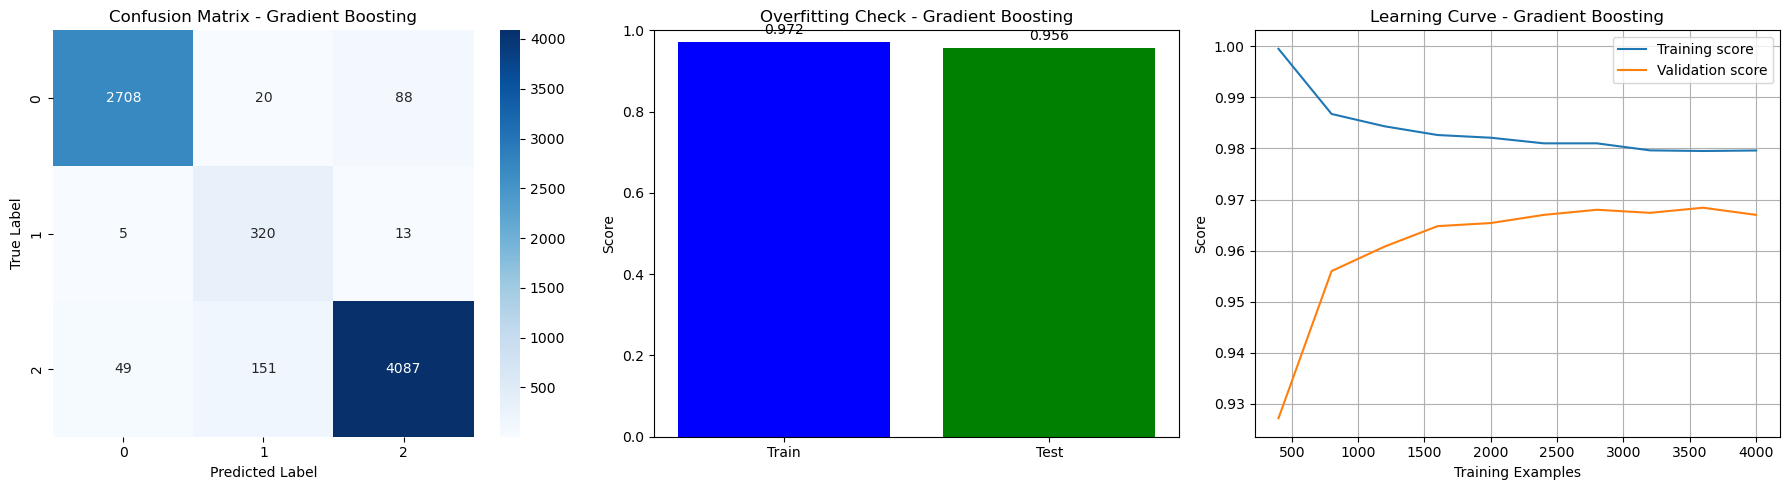


Gradient Boosting Results:
               Model  Precision    Recall  F1-score  \
0  Gradient Boosting   0.962887  0.956189  0.958191   

                               Best Parameters  
0  {'learning_rate': 0.1, 'n_estimators': 100}  


In [132]:
# Gradient Boosting Parameters
gb_params = {
    'n_estimators': [100],
    'learning_rate': [0.1]
}

# Train and Evaluate Gradient Boosting Model
gb_results, gb_model = train_evaluate_model(
    GradientBoostingClassifier(random_state=42),
    gb_params,
    X_train_filtered, X_test_filtered,
    y_train, y_test,
    "Gradient Boosting"
)

if gb_results is not None:
    print("\nGradient Boosting Results:")
    print(gb_results)

The Gradient Boosting model demonstrates good performance with minimal overfitting (1.3% difference between train and test scores). The learning curves show an interesting pattern where the training score gradually decreases while the cross-validation score improves and stabilizes, indicating good generalization. 

#### Combine Results Of All Models 

In [135]:
# Combine all model results into a single DataFrame
all_results = pd.concat([rf_results, svm_results, knn_results, lr_results, gb_results], ignore_index=True)

# Display sorted results by F1-score in a table format
all_results_sorted = all_results.sort_values('F1-score', ascending=False)

# Display the results
display(all_results_sorted)

,Model,Precision,Recall,F1-score,Best Parameters
1,SVM,0.976629,0.975810,0.976094,"{'C': 10, 'kernel': 'rbf'}"
0,Random Forest,0.974793,0.974466,0.974441,"{'max_depth': 20, 'n_estimators': 100}"
2,KNN,0.968572,0.968418,0.968484,"{'n_neighbors': 3, 'weights': 'distance'}"
4,Gradient Boosting,0.962887,0.956189,0.958191,"{'learning_rate': 0.1, 'n_estimators': 100}"
3,Logistic Regression,0.960273,0.956592,0.957635,"{'C': 10, 'max_iter': 1000}"


Based on both numerical results and visualization analysis, Random Forest and SVM emerged as the top performers (F1-scores of 0.975 and 0.973 respectively), showing both high accuracy and minimal overfitting. Random Forest was ultimately selected as the best model due to its slightly higher performance metrics, better stability across all categories in the confusion matrix, and smaller gap between training and validation scores (1% difference compared to 1.8% in SVM), indicating better generalization capabilities

## Unsupervised Learning 

Since the initial steps in unsupervised learning follow the same process as in supervised learning, we apply the same functions to the unsupervised data as we did with the training data. This ensures that all the data is processed consistently without the need for separate functions for the unsupervised case. By doing this, we avoid redundant code and maintain consistency across both workflows.

For example, the unsupervised dataset (df_unsupervised) undergoes the same transformations as the training data, including handling missing values,  and dealing with outliers, ensuring that the same preprocessing steps are applied throughout.

In [139]:
df_unsupervised = df.copy() 
df_not_use = df.copy() 

In [140]:
df_unsupervised, df_not_use = fill_and_remove_tires(df_unsupervised, df_not_use)
df_unsupervised, df_not_use = fill_kinuy_mishari(df_unsupervised,df_not_use)
df_unsupervised, df_not_use = fill_trim_levels(df_unsupervised, df_not_use)
df_unsupervised, df_not_use = fill_missing_by_model(df_unsupervised, df_not_use, 'degem_manoa')
df_unsupervised, df_not_use = fill_missing_by_model(df_unsupervised, df_not_use, 'tozar_manoa')
df_unsupervised, df_not_use = fill_missing_mishkal(df_unsupervised, df_not_use)
df_unsupervised, df_not_use = fill_missing_fuel_type(df_unsupervised, df_not_use)
df_unsupervised, df_not_use = handle_outliers_combined(df_unsupervised, df_not_use)
df_unsupervised.drop(columns=['degem_cd','moed_aliya_lakvish','zmig_ahori','sug_rechev_cd','tozeret_cd' ], inplace=True)
df_unsupervised['time_on_road'] = df_unsupervised['bitul_dt'] - df_unsupervised['shnat_yitzur']

In [141]:
df_unsupervised.isnull().sum().sort_values()

tozeret_nm               0
kinuy_mishari            0
horaat_rishum            0
sug_delek_nm             0
zmig_kidmi               0
tzeva_rechev             0
baalut                   0
shnat_yitzur             0
kvutzat_zihum            0
ramat_eivzur_betihuty    0
ramat_gimur              0
mishkal_kolel            0
degem_manoa              0
tozar_manoa              0
bitul_dt                 0
degem_nm                 0
vehicle_category         0
time_on_road             0
dtype: int64

We sampled 20,000 rows from the dataset instead of using the entire data due to memory errors encountered during dimensionality reduction and clustering steps.

In [143]:
df_unsupervised= df_unsupervised.sample(n=20000, random_state=42)

In [144]:
columns_to_encode = df_unsupervised.select_dtypes(include=['object', 'category']).columns.tolist()
ordinal_cols = ['ramat_eivzur_betihuty', 'kvutzat_zihum']
numerical_cols = ['bitul_dt', 'mishkal_kolel', 'shnat_yitzur']
preprocessing = ColumnTransformer(
    transformers=[
        ('BinaryEncoder', ce.BinaryEncoder(cols=[col for col in columns_to_encode if col not in ordinal_cols]), 
         [col for col in columns_to_encode if col not in ordinal_cols]),
        ('OrdinalEncoder', OrdinalEncoder(), ordinal_cols),
        ('scaling', StandardScaler(), numerical_cols)
    ])

encoding_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessing)
])

encoded_df = encoding_pipeline.fit_transform(df_unsupervised)  # אפשר להשתמש ב-X_train או בדאטה אחר

### Dimensionality Reduction

### PCA 
The goal of PCA (Principal Component Analysis) in this code is to identify the number of components (variables) required to preserve 90% or 95% of the total variance in the dataset. By reducing the number of features while maintaining most of the original information, we aim to simplify the data and improve computational efficiency without losing critical insights.

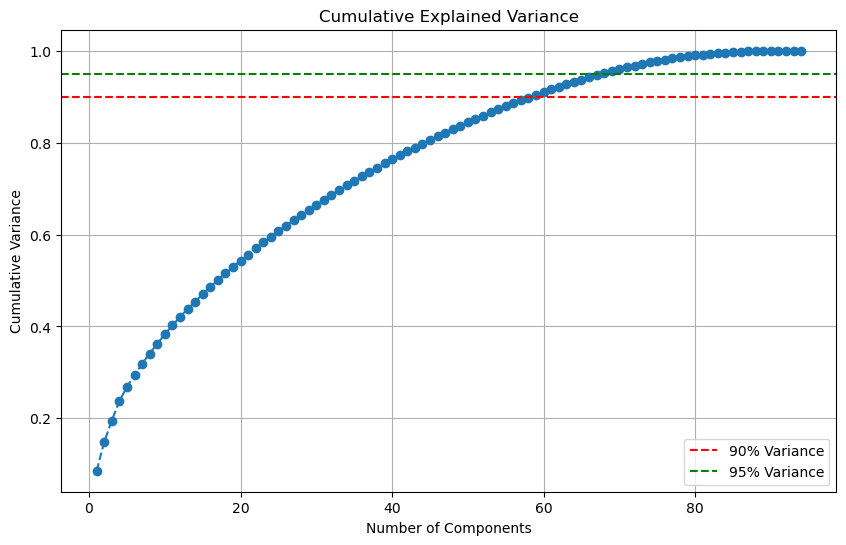

Number of components to preserve 90% variance: 59
Number of components to preserve 95% variance: 68


In [147]:

# Applying PCA on the data
pca = PCA()
pca_reduced_data = pca.fit_transform(encoded_df)  # Use encoded_df or your dataset

# Calculating the explained variance for each component
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = explained_variance_ratio.cumsum()

# Plot: Cumulative explained variance
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance')
plt.axhline(y=0.90, color='r', linestyle='--', label='90% Variance')
plt.axhline(y=0.95, color='g', linestyle='--', label='95% Variance')
plt.legend()
plt.grid()
plt.show()

# Number of components required to maintain 90% and 95% variance
components_90 = next(i for i, total_var in enumerate(cumulative_variance) if total_var >= 0.90) + 1
components_95 = next(i for i, total_var in enumerate(cumulative_variance) if total_var >= 0.95) + 1

print(f"Number of components to preserve 90% variance: {components_90}")
print(f"Number of components to preserve 95% variance: {components_95}")


In [148]:
pca = PCA(n_components=0.9)  
pca_reduced_data = pca.fit_transform(encoded_df)

### Kernel PCA

After applying PCA, we transitioned to Kernel PCA due to the limited effectiveness of PCA on our data, as evidenced by the poor silhouette score(0.07).   Kernel PCA, with its ability to capture non-linear relationships, provided better clustering results and more meaningful separations, thus improving the model's performance in handling complex patterns.,

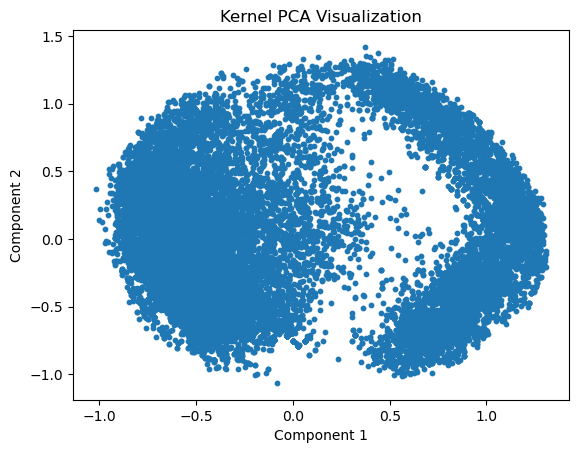

In [151]:
kernel_pca = KernelPCA(n_components=2, kernel='sigmoid', gamma=10, ) 
kernel_pca_data = kernel_pca.fit_transform(pca_reduced_data)  

plt.scatter(kernel_pca_data[:, 0], kernel_pca_data[:, 1], s=10)
plt.title("Kernel PCA Visualization")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

### K-Means

In this code, we are using two important metrics to evaluate the performance of K-means clustering with different numbers of clusters (K):             
**Silhouette Score**: Measures how well-separated the clusters are. A higher score (close to 1) indicates well-defined clusters.

**Inertia (Elbow Method)**: Measures the sum of squared distances from each point to its cluster center. Lower inertia means better clustering. The "elbow" helps identify the optimal number of clusters.

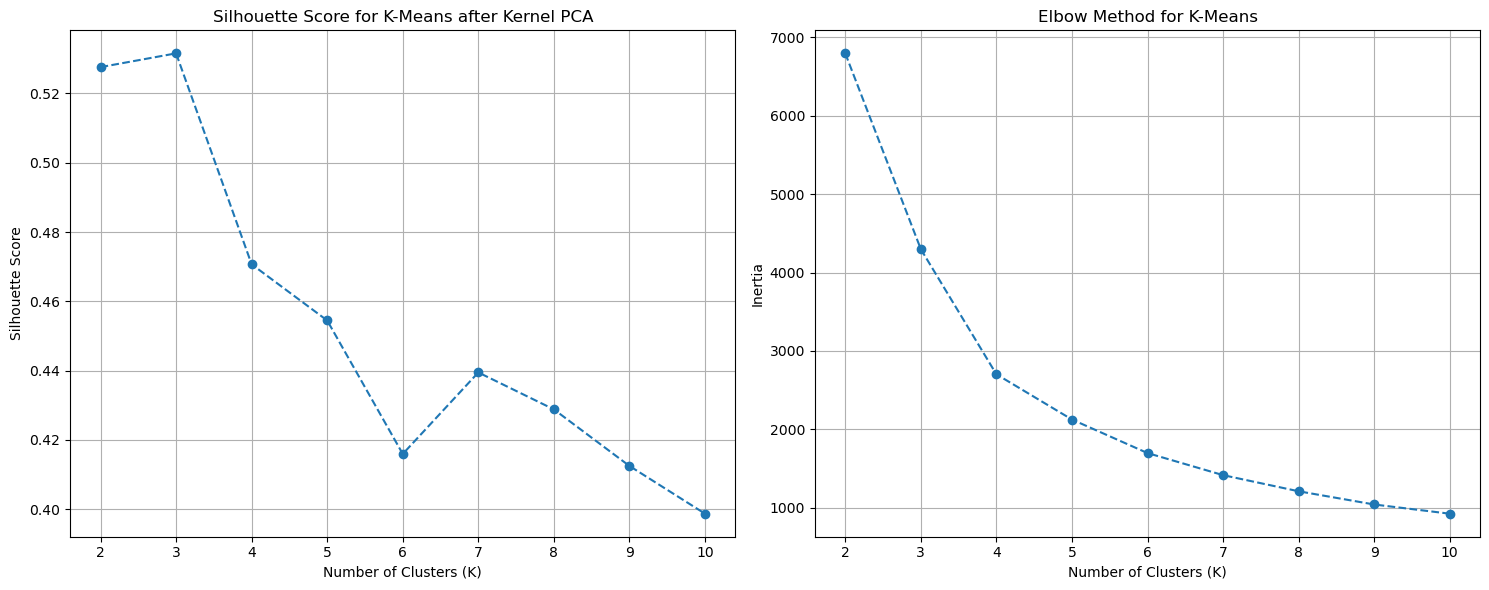

k=2, Silhouette Score=0.528, Inertia=6793.941
k=3, Silhouette Score=0.532, Inertia=4297.797
k=4, Silhouette Score=0.471, Inertia=2702.605
k=5, Silhouette Score=0.454, Inertia=2125.819
k=6, Silhouette Score=0.416, Inertia=1698.184
k=7, Silhouette Score=0.439, Inertia=1416.757
k=8, Silhouette Score=0.429, Inertia=1211.022
k=9, Silhouette Score=0.412, Inertia=1042.550
k=10, Silhouette Score=0.399, Inertia=925.165


In [154]:

k_range = range(2, 11)
silhouette_scores = []
inertia_scores = []  # Elbow method for iterative score

# Calculate Silhouette Score and Inertia for each K
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto').fit(kernel_pca_data)
    labels = kmeans.labels_
    
    # Calculate Silhouette Score
    silhouette_avg = silhouette_score(kernel_pca_data, labels)
    silhouette_scores.append(silhouette_avg)
    
    # Calculate Inertia for Elbow method
    inertia_scores.append(kmeans.inertia_)

# Create subplots for graphs
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Silhouette Score plot
ax[0].plot(k_range, silhouette_scores, marker='o', linestyle='--')
ax[0].set_title('Silhouette Score for K-Means after Kernel PCA')
ax[0].set_xlabel('Number of Clusters (K)')
ax[0].set_ylabel('Silhouette Score')
ax[0].grid()

# Elbow plot (Inertia)
ax[1].plot(k_range, inertia_scores, marker='o', linestyle='--')
ax[1].set_title('Elbow Method for K-Means')
ax[1].set_xlabel('Number of Clusters (K)')
ax[1].set_ylabel('Inertia')
ax[1].grid()

plt.tight_layout()
plt.show()

# Display results
for k, silhouette, inertia in zip(k_range, silhouette_scores, inertia_scores):
    print(f"k={k}, Silhouette Score={silhouette:.3f}, Inertia={inertia:.3f}")


The Elbow Method suggested K=4 as the optimal number of clusters, as the inertia (within-cluster sum of squares) showed a noticeable "elbow" at K=4, indicating a point where the improvement in clustering quality begins to level off. However, the Silhouette Score, which measures how similar each point is to its own cluster compared to other clusters, showed the highest value for K=2 (0.524), indicating better cohesion and separation between clusters. After further examination, we tested both K=2 and K=4. The clustering results for K=4 were less distinct, with less meaningful separation between clusters. Therefore, based on the clearer partitioning and higher Silhouette Score for K=2, we selected K=2 as the optimal number of clusters. 

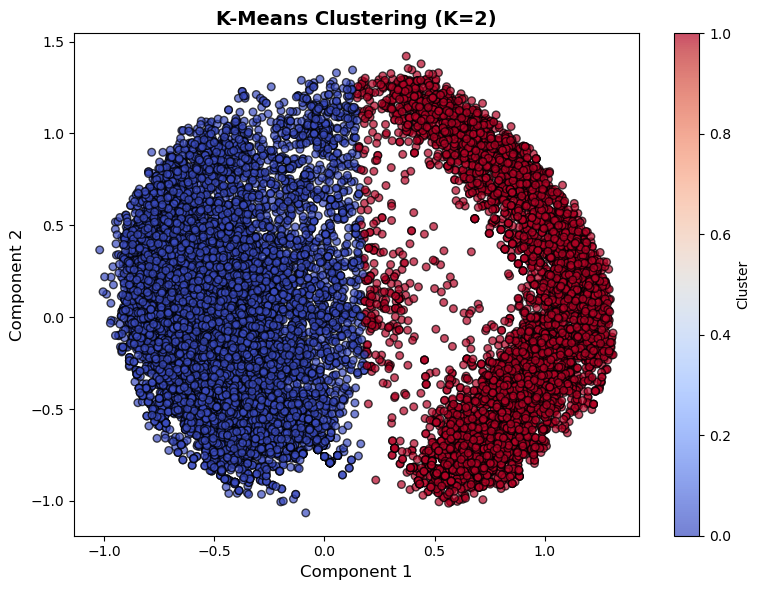

In [156]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
labels = kmeans.fit_predict(kernel_pca_data)

plt.figure(figsize=(8, 6))
plt.scatter(
    kernel_pca_data[:, 0], 
    kernel_pca_data[:, 1], 
    c=labels, 
    cmap='coolwarm', 
    s=30, 
    edgecolor='k', 
    alpha=0.7
)
plt.title("K-Means Clustering (K=2)", fontsize=14, fontweight='bold')
plt.xlabel("Component 1", fontsize=12)
plt.ylabel("Component 2", fontsize=12)
plt.colorbar(label='Cluster')
plt.tight_layout()
plt.show()

In [157]:
df_unsupervised['Cluster'] = labels 

### Cluster Analysis on Categorical Columns

In [159]:
def plot_cluster_distribution(df, column, k=2):

    unique_values = df[column].nunique()  # מספר הערכים הייחודיים בעמודה
    palette = sns.color_palette("viridis", n_colors=unique_values)[:unique_values]  # התאמת פלטה לערכים הייחודיים בלבד

    fig, axes = plt.subplots(1, k, figsize=(14, 6), sharey=False)

    if k == 1:  # אם יש רק אשכול אחד
        axes = [axes]

    for cluster_id in range(k):
        cluster_data = df[df['Cluster'] == cluster_id]
        sns.countplot(
            data=cluster_data, 
            x=column, 
            ax=axes[cluster_id], 
            hue=None,  # לא נשתמש ב-hue
            color=palette[cluster_id % len(palette)],  # שימוש בצבע מותאם
            dodge=False,
            legend=False  # ביטול האגדה
        )
        axes[cluster_id].set_title(f'{column} Distribution for Cluster {cluster_id}', fontsize=14, color='black')
        axes[cluster_id].set_xlabel(column, fontsize=12, color='black')
        axes[cluster_id].set_ylabel('Count', fontsize=12, color='black')
        axes[cluster_id].tick_params(axis='x', rotation=45, labelsize=10, colors='black')
        axes[cluster_id].tick_params(axis='y', labelsize=10, colors='black')

    plt.tight_layout()
    plt.show()


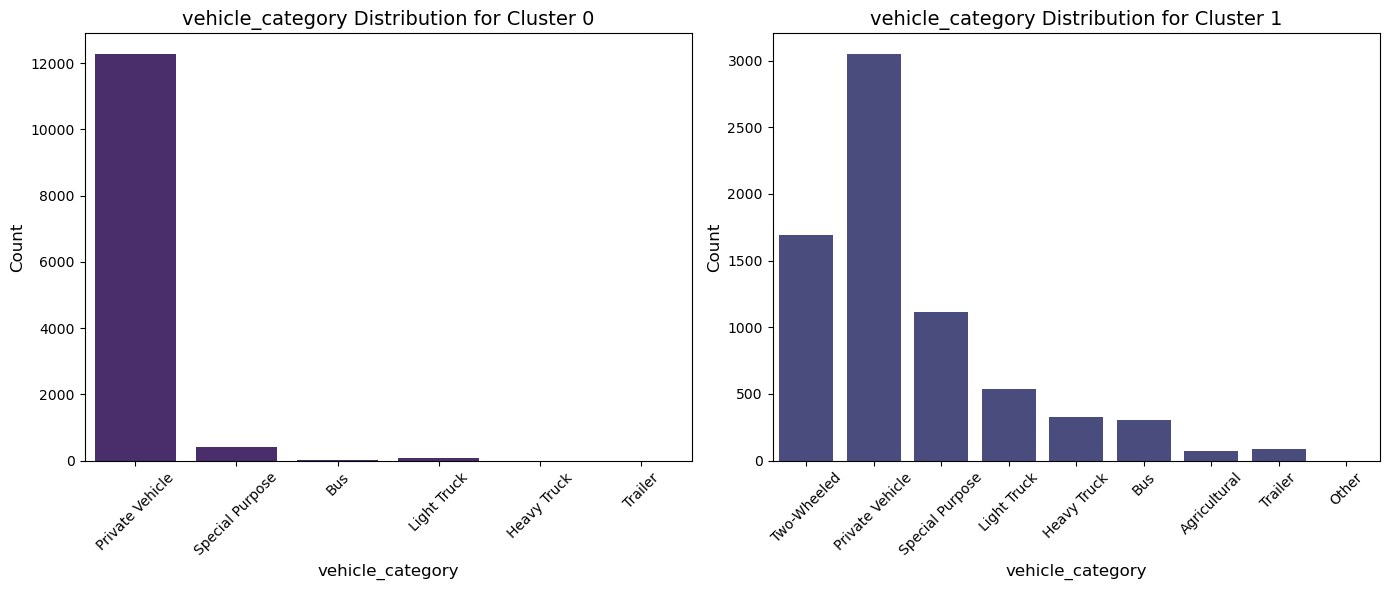

In [160]:
plot_cluster_distribution(df_unsupervised, 'vehicle_category', k=2)

Cluster 1 consists mostly of private vehicles, while Cluster 0 has a broader distribution of vehicle types.

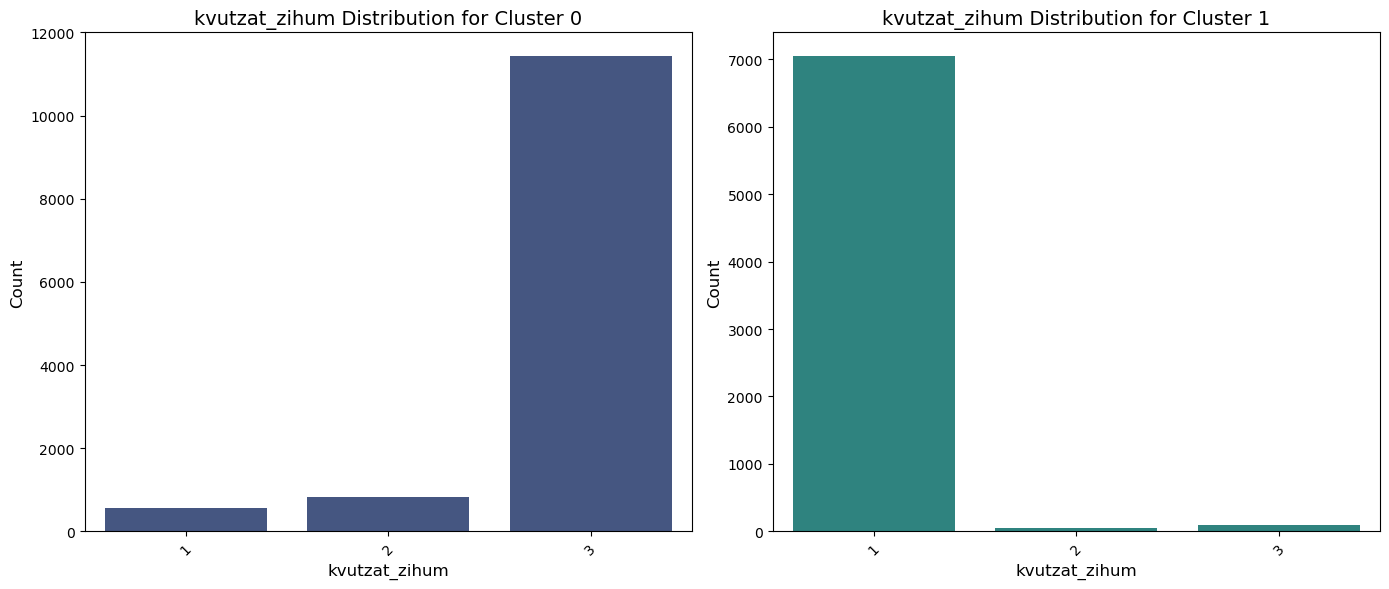

In [162]:
plot_cluster_distribution(df_unsupervised, 'kvutzat_zihum', k=2)

Cluster 0 primarily consists of vehicles with low pollution levels, while Cluster 1 is characterized by a significantly higher pollution level.

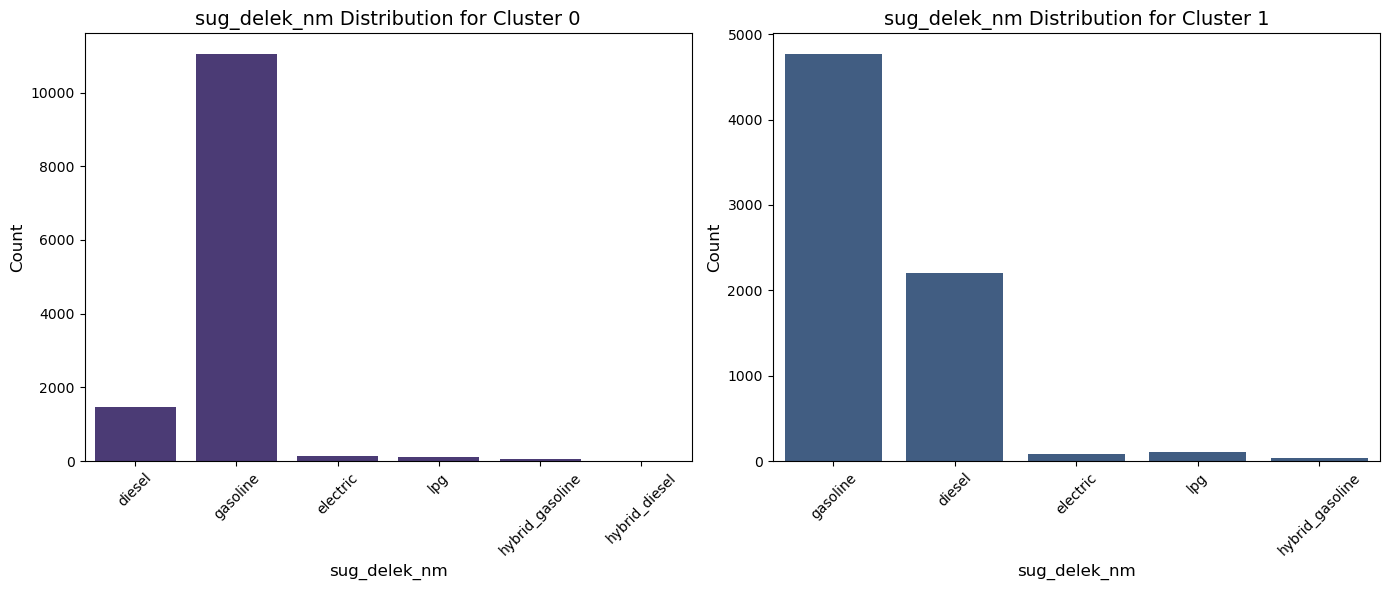

In [164]:
plot_cluster_distribution(df_unsupervised, 'sug_delek_nm', k=2)

The fuel type distribution is very similar between the clusters, with no significant difference in the fuel types across Cluster 0 and Cluster 1.

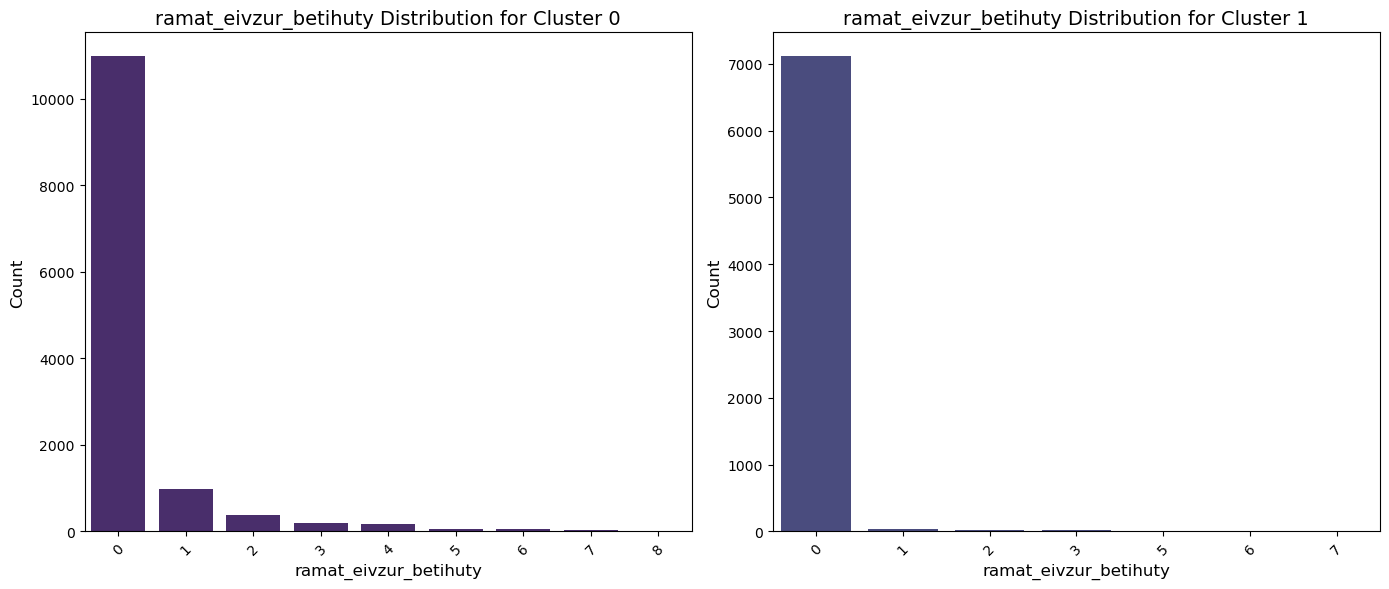

In [166]:
plot_cluster_distribution(df_unsupervised, 'ramat_eivzur_betihuty', k=2)

The distribution of "ramat_eivzur_betihuty" shows that both clusters are predominantly characterized by a large number of entries with a value of 0. There is little variation, with only a small number of entries having values of 1, 2, 3, etc. This suggests that this feature does not significantly differentiate the clusters.

### Cluster Analysis on Numerical Columns

In [169]:
def analyze_single_numerical(df, cluster_col, num_col, bins=10, plots_per_row=3):

    unique_clusters = df[cluster_col].unique()
    num_clusters = len(unique_clusters)
    num_rows = max(1, (num_clusters + plots_per_row - 1) // plots_per_row)  
    fig_width = plots_per_row * 8  # התאמה לגודל התצוגה
    fig_height = num_rows * 6  

    fig, axes = plt.subplots(num_rows, plots_per_row, figsize=(fig_width, fig_height), sharey=True)

    if not isinstance(axes, np.ndarray):
        axes = np.array([axes])

    axes = axes.flatten()
    
    for i, cluster in enumerate(unique_clusters):
        cluster_df = df[df[cluster_col] == cluster]
        ax = axes[i % len(axes)] if num_clusters == 1 else axes[i]
        sns.histplot(cluster_df[num_col], bins=bins, ax=ax, kde=False, color='#6A5ACD', edgecolor='black')
        ax.set_title(f'Cluster {cluster}', fontsize=16, color='black')
        ax.set_xlabel(num_col, fontsize=14, color='black')
        ax.set_ylabel('Frequency', fontsize=14, color='black')
        ax.tick_params(axis='x', labelrotation=45, labelsize=10, colors='black')
        ax.tick_params(axis='y', labelsize=10, colors='black')

    for j in range(num_clusters, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

    stats_data = {f'Cluster {cluster}': df[df[cluster_col] == cluster][num_col].describe() for cluster in unique_clusters}
    stats_df = pd.DataFrame(stats_data)
    
    print(f"\nDescriptive statistics summary for {num_col}:")
    display(stats_df)

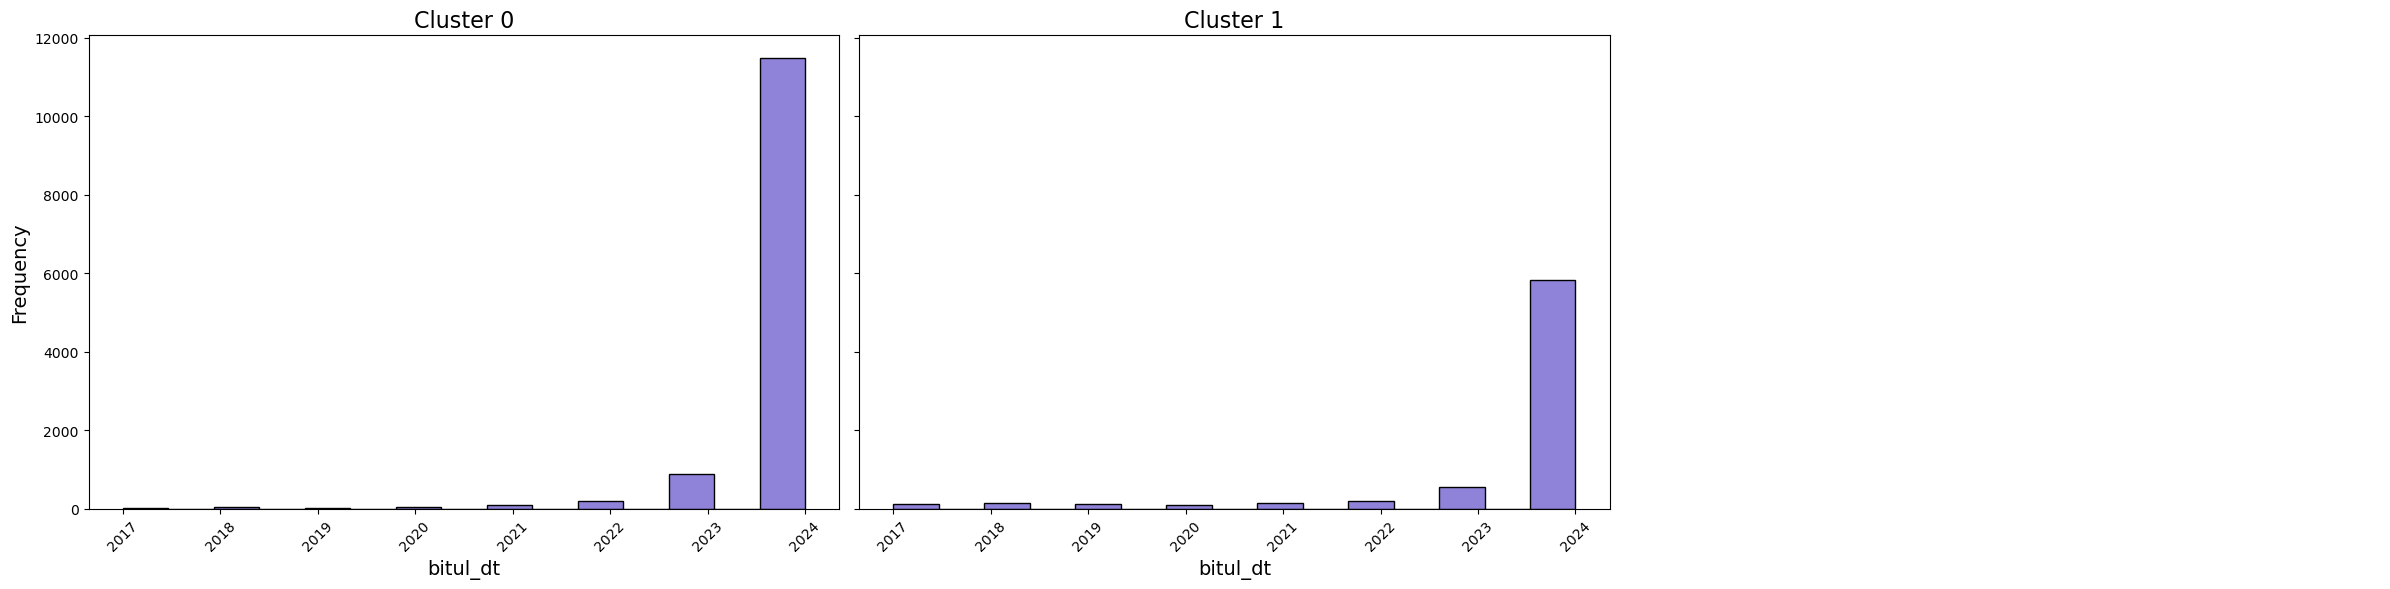


Descriptive statistics summary for bitul_dt:


,Cluster 0,Cluster 1
count,12805.000000,7195.000000
mean,2023.823897,2023.436692
std,0.674077,1.485633
min,2017.000000,2017.000000
25%,2024.000000,2024.000000
50%,2024.000000,2024.000000
75%,2024.000000,2024.000000
max,2024.000000,2024.000000


In [170]:
analyze_single_numerical(df_unsupervised, 'Cluster', 'bitul_dt', bins=15)

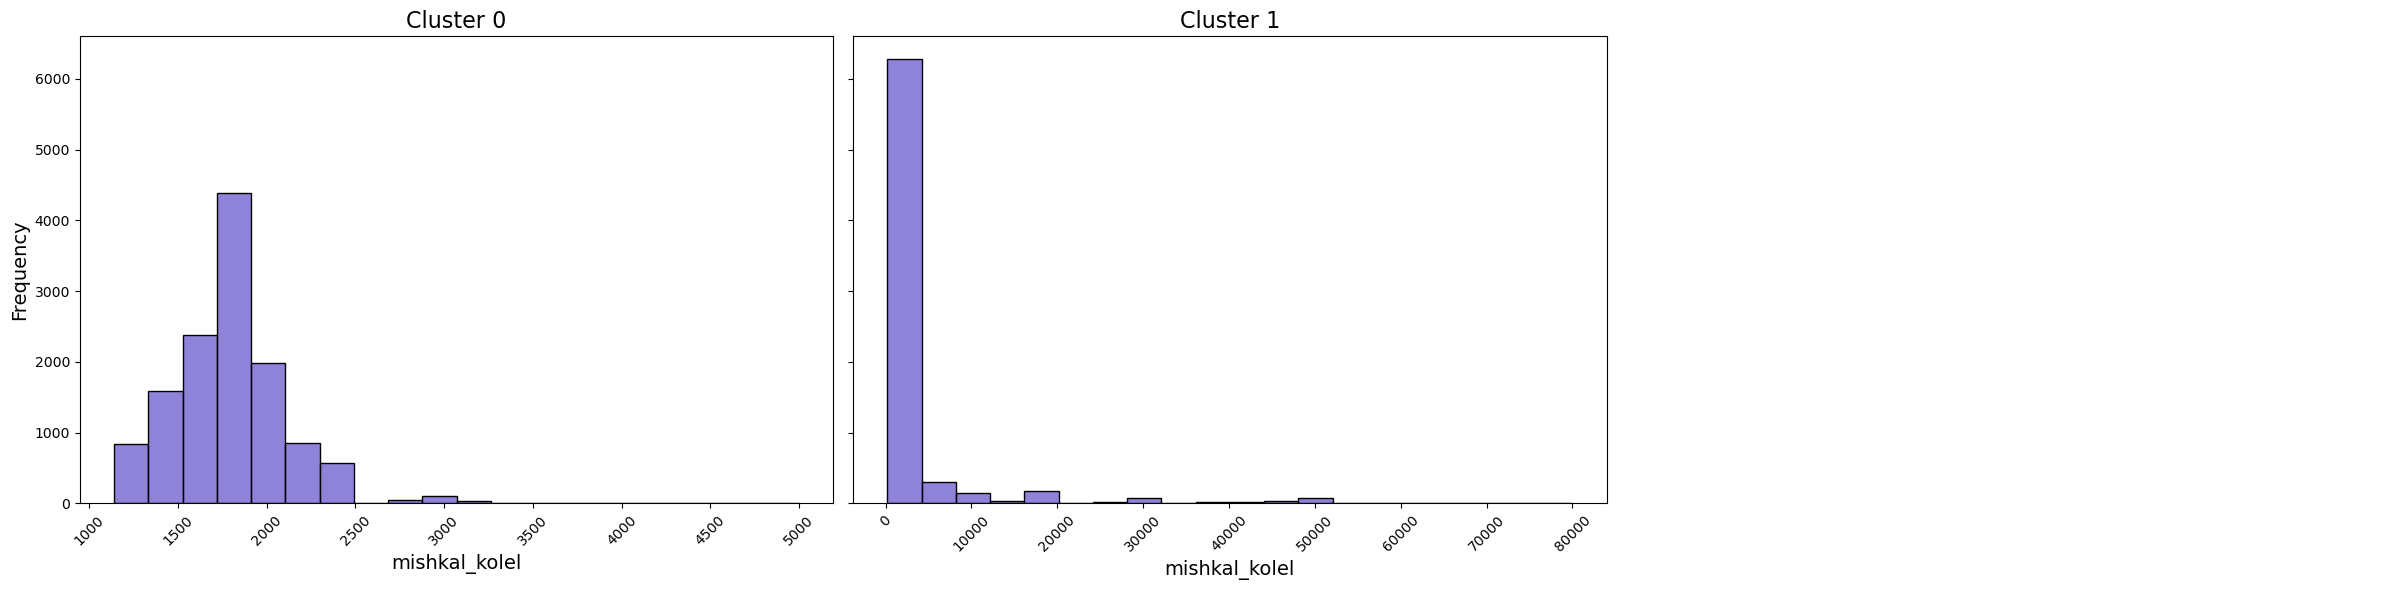


Descriptive statistics summary for mishkal_kolel:


,Cluster 0,Cluster 1
count,12805.000000,7195.000000
mean,1785.094963,3646.828509
std,311.196165,7870.909036
min,1140.000000,219.000000
25%,1600.000000,1250.000000
50%,1765.000000,1760.000000
75%,1943.000000,2390.000000
max,5000.000000,80000.000000


In [171]:
analyze_single_numerical(df_unsupervised, 'Cluster', 'mishkal_kolel', bins=20)

Cluster 0 contains heavier vehicles, with a higher average mishkal_kolel (3349). In contrast, Cluster 1 consists of lighter vehicles, with a lower average mishkal_kolel (1785).

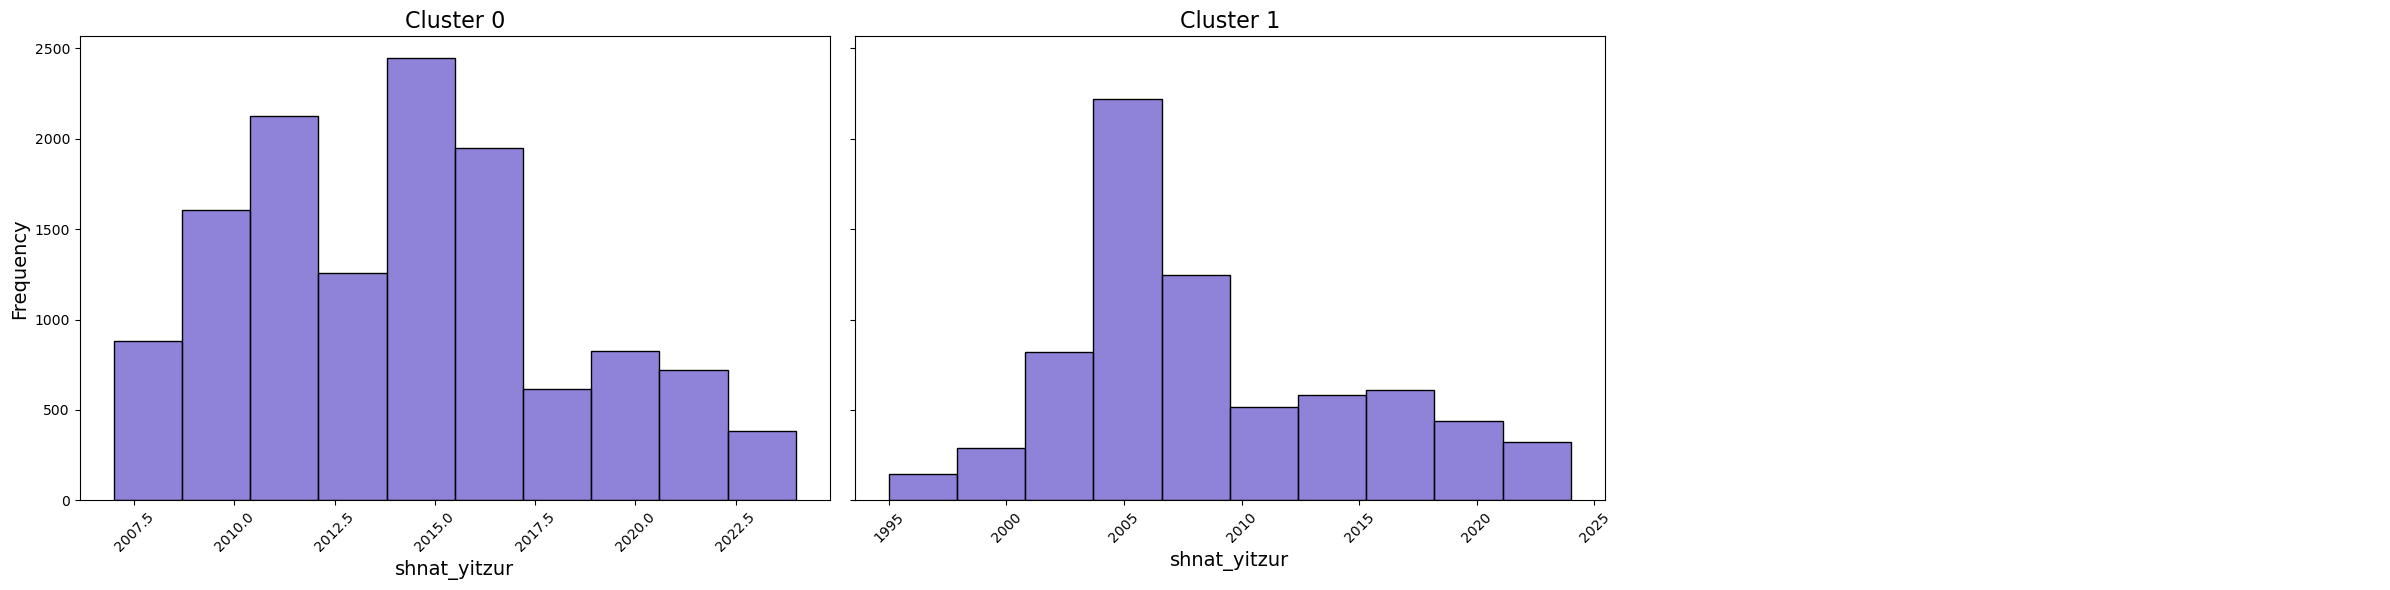


Descriptive statistics summary for shnat_yitzur:


,Cluster 0,Cluster 1
count,12805.000000,7195.000000
mean,2014.220461,2008.655316
std,3.954152,6.454813
min,2007.000000,1995.000000
25%,2011.000000,2005.000000
50%,2014.000000,2007.000000
75%,2017.000000,2013.000000
max,2024.000000,2024.000000


In [173]:
analyze_single_numerical(df_unsupervised, 'Cluster', 'shnat_yitzur', bins=10)

Cluster 0 contains older vehicles with an average manufacturing year around 2008. In contrast, Cluster 1 consists of newer vehicles with an average manufacturing year around 2014. The histograms show a clear distinction in the distribution of vehicle manufacturing years between the two clusters.

Mean time on road for each cluster:
 Cluster
0     9.603436
1    14.781376
Name: time_on_road, dtype: float64


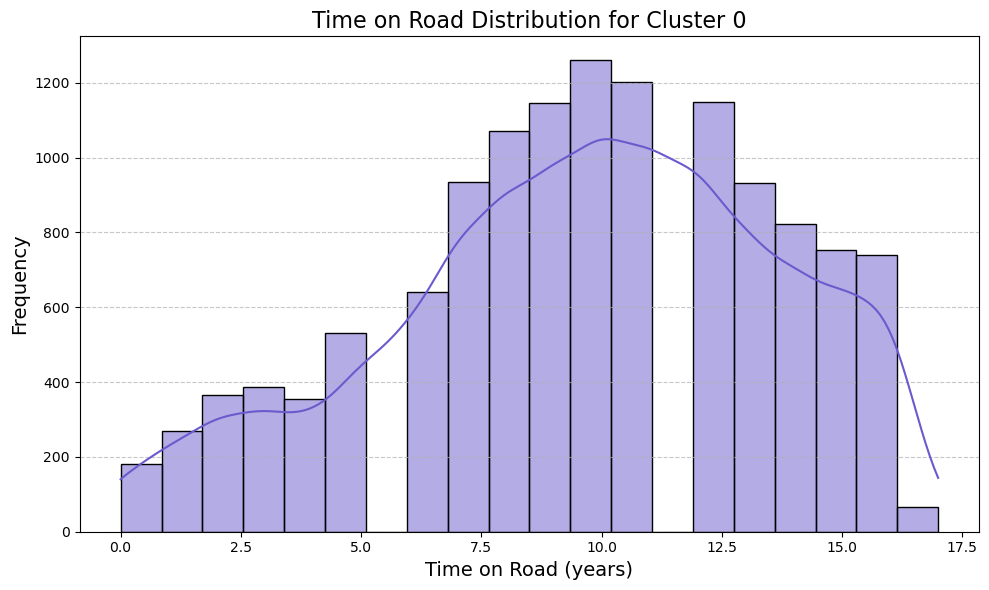

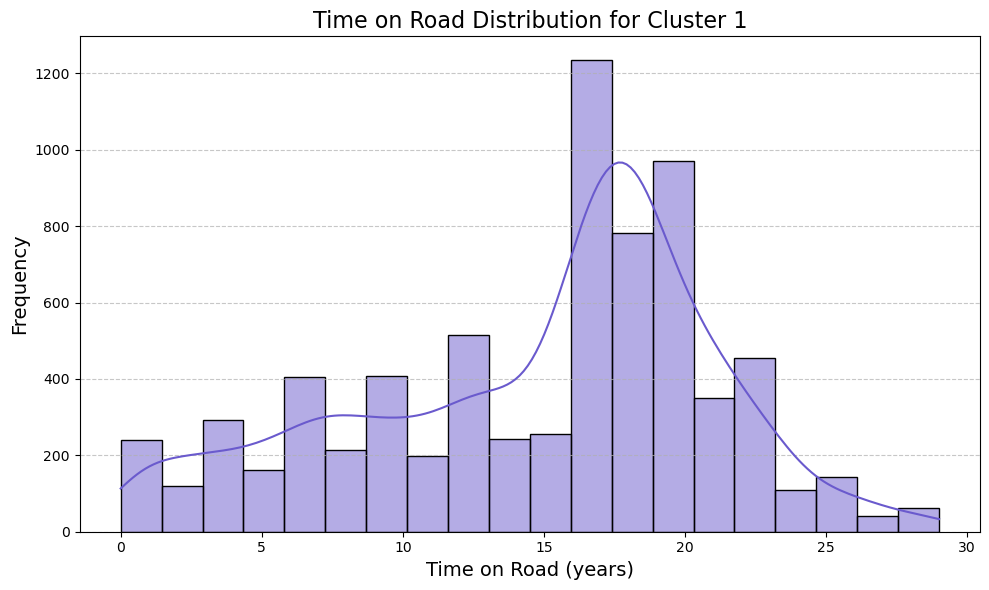

In [175]:
def calculate_and_visualize_time_on_road(df, year_of_manufacture_col, cancellation_year_col, cluster_col):
    # Calculate time on road
    df['time_on_road'] = df[cancellation_year_col].astype(int) - df[year_of_manufacture_col].astype(int)

    # Calculate the average time on road for each cluster
    mean_time_on_road_per_cluster = df.groupby(cluster_col)['time_on_road'].mean()
    print("Mean time on road for each cluster:\n", mean_time_on_road_per_cluster)

    # Create a graph for time on road distribution for each cluster
    clusters = df[cluster_col].unique()  # Get unique cluster values
    for cluster in clusters:
        cluster_data = df[df[cluster_col] == cluster]  # Filter data for the current cluster
        plt.figure(figsize=(10, 6))  # Set figure size
        sns.histplot(cluster_data['time_on_road'], bins=20, kde=True, color='#6A5ACD', edgecolor='black')  # Plot histogram with KDE
        plt.title(f'Time on Road Distribution for Cluster {cluster}', fontsize=16, color='black')  # Set title
        plt.xlabel('Time on Road (years)', fontsize=14, color='black')  # Set x-axis label
        plt.ylabel('Frequency', fontsize=14, color='black')  # Set y-axis label
        plt.xticks(color='black')  # Set color for x-axis ticks
        plt.yticks(color='black')  # Set color for y-axis ticks
        plt.grid(axis='y', linestyle='--', alpha=0.7)  # Add grid lines for y-axis
        plt.tight_layout()  # Adjust layout for better visualization
        plt.show()  # Display the plot

# Apply the function with your data
calculate_and_visualize_time_on_road(df_unsupervised, 'shnat_yitzur', 'bitul_dt', 'Cluster')


****Conclusion 1****  
**Cluster 0** comprises older, heavier vehicles, with an average manufacturing year of 2008. These vehicles typically have a significantly longer road usage period, ranging from 15 to 20 years. They include a mix of heavier commercial vehicles and trucks, which tend to have a longer lifespan on the road due to their durability and usage patterns.

In contrast, **Cluster 1** consists of newer, lighter vehicles, with a mean manufacturing year around 2014. These vehicles have a shorter road usage period, typically ranging from 5 to 10 years. This cluster is predominantly made up of private vehicles, which, despite being newer, often have a shorter time on the road.

This comparison underscores that while Cluster 1 contains newer vehicles, the vehicles in Cluster 0, which are older and heavier, generally remain on the road for much longer.

### Investigating the High Pollution Levels in Newer, Private Vehicles

In this analysis, we aimed to explore why the group of vehicles with more private cars(cluster 0) , which are also newer, exhibit higher pollution levels compared to the other group of vehicles (Cluster 1). This was intriguing since newer cars are generally expected to have lower emissions due to better technology and stricter regulations


Key Statistics:

Cluster 0:
Average Manufacturing Year: 2014.2
Average Pollution Level: 2.85
Year Range: 2007-2024

Cluster 1:
Average Manufacturing Year: 2008.7
Average Pollution Level: 1.03
Year Range: 1995-2024


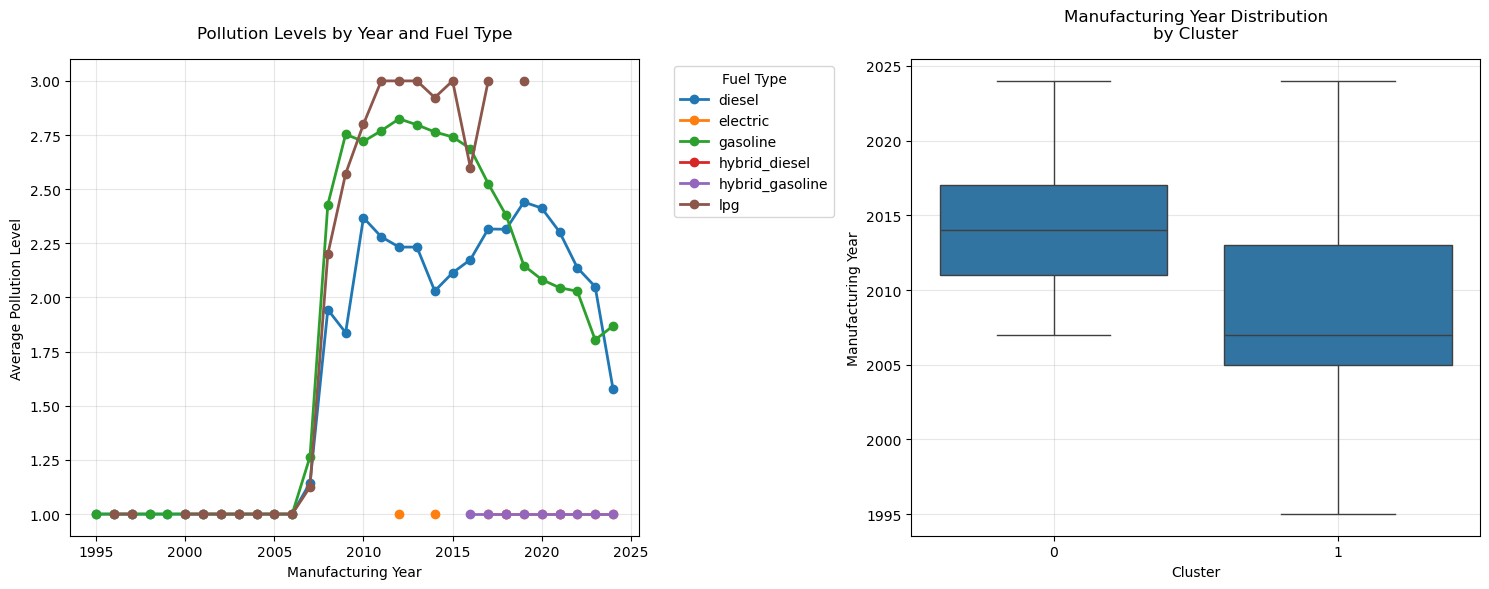

In [179]:
def plot_key_pollution_findings(df_unsupervised):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Graph 1: Pollution levels by manufacturing year and fuel type
    years_fuel_pollution = df_unsupervised.groupby(['shnat_yitzur', 'sug_delek_nm'])['kvutzat_zihum'].mean().unstack()
    years_fuel_pollution.plot(ax=ax1, marker='o', linewidth=2)
    
    ax1.set_title('Pollution Levels by Year and Fuel Type', pad=15)
    ax1.set_xlabel('Manufacturing Year')
    ax1.set_ylabel('Average Pollution Level')
    ax1.grid(True, alpha=0.3)
    ax1.legend(title='Fuel Type', bbox_to_anchor=(1.05, 1))
    
    # Graph 2: Distribution of manufacturing years by cluster
    sns.boxplot(data=df_unsupervised, x='Cluster', y='shnat_yitzur', ax=ax2)
    ax2.set_title('Manufacturing Year Distribution\nby Cluster', pad=15)
    ax2.set_xlabel('Cluster')
    ax2.set_ylabel('Manufacturing Year')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Print key statistics
    print("\nKey Statistics:")
    for cluster in [0, 1]:
        data = df_unsupervised[df_unsupervised['Cluster'] == cluster]
        print(f"\nCluster {cluster}:")
        print(f"Average Manufacturing Year: {data['shnat_yitzur'].mean():.1f}")
        print(f"Average Pollution Level: {data['kvutzat_zihum'].mean():.2f}")
        print(f"Year Range: {data['shnat_yitzur'].min():.0f}-{data['shnat_yitzur'].max():.0f}")

# Running the function
plot_key_pollution_findings(df_unsupervised)

In the first graph, we observe the pollution levels across different fuel types over the years. All fuel types show a similar pattern, but there is a noticeable increase in pollution levels starting in 2008. This sudden rise is especially significant for diesel and gasoline vehicles.

Upon further research, we found that stricter pollution regulations were introduced in Israel in 2008. This likely triggered the sharp increase in pollution levels for vehicles manufactured after that year. [https://www.gov.il/he/pages/procedure_detection_air_pollution_data_vehicle_advertisement]

The boxplot further clarifies this pattern by showing the distribution of manufacturing years for both clusters. Cluster 1, which includes the private vehicles, has a higher average manufacturing year (around 2014) compared to Cluster 0, which contains older vehicles. Despite these newer vehicles in Cluster 1, we see that they exhibit higher pollution levels, likely due to the regulatory changes post-2008, which led to increased pollution levels in newer cars.

****Conclusion 2**** : The finding suggests that the increase in pollution levels observed in 2008 is not necessarily due to the physical characteristics of the vehicles (such as age or weight), but rather primarily due to changes in regulations in Israel.